In [1]:
"""
Sub-Rayleigh two-tone frequency estimation:
local NLS, global MLE, uniform-prior MMSE, and ANE.

================================================================
WHY THE MMSE CURVE MOVES WHEN THE FREQUENCY PAIR CHANGES
================================================================

Observation to be explained: with (phi2 - phi1) < 2*pi/N, the MMSE
curve looks noticeably different for (0.40pi, 0.42pi), (0.78pi,
0.80pi) and (0.80pi, 0.82pi), while NLS/MLE/ANE move much less.

There are three causes, and only the first is a genuine property of
the estimator.

(1) PRIOR-MEAN FLOOR  (dominant, real, and pair-specific)
    MMSE is the posterior mean under a uniform prior on the ordered
    domain {phi_min <= phi1 < phi2 <= phi_max}. As SNR -> -inf the
    posterior becomes flat and the estimate tends to the PRIOR MEAN

        E[phi1] = lo + (hi-lo)/3,   E[phi2] = lo + 2(hi-lo)/3
                ~ (0.333 pi, 0.667 pi).

    Because the Monte Carlo is run at a single FIXED theta_true (a
    frequentist evaluation of a Bayesian estimator), the low-SNR
    plateau of the MMSE curve is exactly

        floor(theta_true) = ||theta_true - E_prior[theta]||^2.

    For N = 64 this floor is

        (0.40pi, 0.42pi) -> 0.644 rad^2
        (0.78pi, 0.80pi) -> 2.144 rad^2
        (0.80pi, 0.82pi) -> 2.381 rad^2

    i.e. a factor of 3.7 between the first and the last pair. That
    single number sets where the MMSE plateau sits and therefore
    where it crosses the other curves. Nothing is wrong: it is the
    correct behaviour of a Bayes estimator evaluated off the prior
    centroid. But it must be stated, not left implicit.

(2) GRID ALIGNMENT ARTEFACTS  (spurious, must be removed)
    With N = 64 the DFT bin spacing is 2*pi/N = 0.03125 pi.
        0.78 pi = 24.96 bins  -> essentially ON DFT bin 25.
    With the old 140-point posterior grid (step 0.00719 pi),
        0.82 pi lands 0.008 grid steps from a node -> essentially ON
        a posterior grid node.
    Both coincidences flatter the corresponding estimator at high
    SNR and are pure artefacts of the chosen pair.

(3) THE ENTROPY -> MLE FALLBACK  (spurious, must be removed)
    The previous code replaced the posterior mean by the global MLE
    whenever the normalised posterior entropy exceeded 0.90. That is
    a hard, SNR- and pair-dependent switch: it puts a kink in the
    MMSE curve at a different SNR for every frequency pair, and the
    result is no longer a posterior mean. When the posterior is flat
    the posterior mean IS the prior mean, and that is the right
    answer.

What does NOT change with the pair: the CRB. For the three pairs
above the joint CRB differs by only ~7%, so the high-SNR asymptote
is essentially pair-independent. The pair dependence lives entirely
in the low-SNR / threshold region.

================================================================
RECOMMENDED PAIR FOR THE PAPER
================================================================

    phi1 = 0.40 pi,  phi2 = 0.42 pi,  N = 64

reported as: centre 0.41 pi, separation 0.02 pi = 0.64 x Rayleigh.

Reasons:
  * Mid-band. 12.8 Rayleigh widths from DC and 18.6 from pi, so no
    band-edge or self-image degeneracy (cos(n phi) merges with its
    negative-frequency image near 0 and pi).
  * Off-bin. DFT-bin fractional offsets 0.80 and 0.44; neither tone
    sits on a DFT bin, unlike 0.78 pi.
  * Off-grid. Neither tone sits on a posterior grid node (the grid
    origin is chosen automatically below to guarantee this).
  * Smallest and least idiosyncratic prior-mean floor of the three
    candidates, so the MMSE plateau does not dominate the figure.
  * 2*phi is far from 0 and 2*pi, so the self-interference term
    Sum n^2 cos(2 n phi) in the Fisher information is small
    (-1.3% at 0.42 pi vs +2.9% at 0.82 pi).

The other two pairs are kept as presets so the claim can be checked
rather than asserted, and RUN_PAIR_ROBUSTNESS sweeps the centre
frequency to show the conclusions are centre-independent.

================================================================
CHANGES RELATIVE TO THE PREVIOUS VERSION
================================================================
 1. Pair parameterised as (centre, separation-in-Rayleigh-units).
 2. Prior stated explicitly; analytic no-information floor computed,
    printed, and overlaid on the plots.
 3. Entropy -> MLE fallback removed (opt-in, default OFF).
 4. Posterior grid refined 140 -> 401 points, evaluated by a
    chunked streaming log-sum-exp so memory stays bounded.
 5. Posterior grid origin auto-offset so no true frequency sits on
    a node.
 6. Local posterior refinement fully batched (was a per-sample
    Python loop): same result, far faster, no per-sample branching.
 7. CRB computed and plotted.
 8. Pair-robustness sweep over centre frequency added.
 9. Separation sweep expressed in Rayleigh units.
10. Monte Carlo stopping rule no longer blocked by the outlier gate
    outside the threshold region.

The script is self-contained and runs as-is.
"""

import math
import time

import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

FAST = True

SEED = 20260817

SNR_DB = np.arange(-14.0, 1.0, 1.0)
KNEE_DB = (-12.0, -4.0)

# ANE bank size. Must be even when ANTITHETIC=True.
K = 8

# ---------------- Observation length ----------------
N_SAMPLES = 64

# Rayleigh (Fourier) resolution limit in rad.
RAYLEIGH = 2.0 * np.pi / N_SAMPLES

# ---------------- Frequency pair ----------------
# Parameterised as centre + separation so that the separation can be
# quoted in Rayleigh units, which is what the reader cares about.
#
#   phi1 = (centre - sep/2),   phi2 = (centre + sep/2)
#
# sep_pi = 0.02  <=>  0.02*pi / (2*pi/64) = 0.64 * Rayleigh.

PAIR_PRESETS = {
    # Recommended for the paper: mid-band, off-bin, off-grid.
    "recommended": dict(center_pi=0.41, sep_pi=0.02),
    # Mid-band alternative, symmetric about the prior centroid gap.
    "midband_alt": dict(center_pi=0.43, sep_pi=0.06),
    # Upper-band candidate (0.78pi, 0.80pi). 0.78pi is ON DFT bin 25.
    "upper_78_80": dict(center_pi=0.79, sep_pi=0.02),
    # Upper-band candidate (0.80pi, 0.82pi). Previous default.
    "upper_80_82": dict(center_pi=0.81, sep_pi=0.02),
}

PAIR_CHOICE = "midband_alt"

CENTER_PI = PAIR_PRESETS[PAIR_CHOICE]["center_pi"]
SEP_PI = PAIR_PRESETS[PAIR_CHOICE]["sep_pi"]

PHI1_TRUE = (CENTER_PI - 0.5 * SEP_PI) * np.pi
PHI2_TRUE = (CENTER_PI + 0.5 * SEP_PI) * np.pi

# ---------------- Training ----------------
ALPHA_GRID = np.array(
    [0.0, 0.15, 0.30, 0.45, 0.60, 0.80, 1.0, 1.5, 2.2, 3.0, 4.0],
    dtype=float,
)

TRAIN_L = 3000 if FAST else 40000
TRAIN_L_KNEE = 12000 if FAST else 60000

REFINE = True
REFINE_DB = (0.0, 16.0)
REFINE_ITERS = 15 if FAST else 80

# Independent validation set.
VAL_FRAC = 1.0

# Statistical validation gate.
SIG_Z = 3.0
MIN_REL_GAIN = 0.02

# Perturbation constraints.
MAX_NORM_SIG = 4.0
ZERO_MEAN = True
ANTITHETIC = True

# ---------------- Frequency search ----------------
GRID_NLS = 1024

# Posterior grid for MLE/MMSE. Refined from 140 -> 401. The ordered
# candidate set has G2*(G2-1)/2 members, evaluated in chunks so the
# memory cost is O(batch * MMSE_CAND_CHUNK) rather than O(batch * M).
# On a CPU-only machine the scan dominates the runtime; 281 is a
# reasonable compromise and still ~2x finer than the old 140.
GRID_MMSE_2D = 401

# Choose the grid origin so that no true frequency sits on a node.
MMSE_GRID_AUTO_OFFSET = True
MMSE_GRID_OFFSET_TRIALS = 401
MMSE_MIN_NODE_DIST = 0.20  # in grid steps; warn below this

# Candidate-chunk size for the streaming posterior scan. Peak
# temporary memory is about 2 * MC_BATCH_PT * MMSE_CAND_CHUNK * 8
# bytes; raise it on a GPU for speed, lower it if memory is tight.
MMSE_CAND_CHUNK = 2048

# Cache the candidate signal matrix if it fits in this many bytes.
MMSE_CACHE_BYTES = 256 * 1024 * 1024

# ---------------- MMSE local refinement ----------------
MMSE_REFINE = True
MMSE_REFINE_PASSES = 3
MMSE_REFINE_POINTS = 21
MMSE_REFINE_SHRINK = 0.35
MMSE_REFINE_SAMPLE_CHUNK = 256

# Replace the posterior mean by the global MLE when the posterior is
# nearly flat. This is NOT a posterior mean and introduces a
# pair-dependent kink in the MMSE curve. Kept only for comparison.
MMSE_FLAT_FALLBACK = False
MMSE_FLAT_ENTROPY = 0.90

# Newton refinement.
NEWTON_STEPS_2D = 5
NEWTON_MAX_STEP_GRID = 2.0
NEWTON_BACKTRACK = 8

# ---------------- Monte Carlo ----------------
MC_BATCH_PT = 4000
MC_MAX = 100000 if FAST else 400000
MC_TOL = 0.05
MC_MIN_OUT = 10

TRIALS = 4000 if FAST else 100000
TRIALS_KNEE = 12000 if FAST else 200000

# ---------------- Separation sweep ----------------
RUN_SEPARATION_SWEEP = True

# Expressed in Rayleigh units. 0.64 is the value used in the main
# experiment, so the sweep passes through the headline operating
# point.
SEPARATIONS_RAYLEIGH = np.array(
    [0.32, 0.48, 0.64, 0.96, 1.60, 2.56],
    dtype=float,
)

SEPARATION_SNR_DB = np.array([-12.0, -8.0, -4.0, 0.0], dtype=float)

SEPARATION_TRIALS = 12000 if FAST else 50000

# ---------------- Pair-robustness sweep ----------------
# Repeats the SNR sweep at several centre frequencies with the
# separation held fixed. Demonstrates that the ordering of the
# curves does not depend on the chosen pair, and that the MMSE
# spread is explained by the prior-mean floor.
RUN_PAIR_ROBUSTNESS = True

ROBUST_CENTERS_PI = np.array(
    [0.31, 0.41, 0.51, 0.61, 0.71, 0.81],
    dtype=float,
)

ROBUST_SNR_DB = np.array([-14.0, -10.0, -6.0, -2.0, 2.0], dtype=float)

ROBUST_TRIALS = 6000 if FAST else 40000

# ---------------- Output ----------------
OUTPUT_NPZ = "fig_two_freq_results_v3.npz"
OUTPUT_PDF = "Fig_two_freq_joint.pdf"
OUTPUT_SEP_NPZ = "fig_two_freq_separation_v3.npz"
OUTPUT_ROBUST_NPZ = "fig_two_freq_robustness_v3.npz"

# ============================================================
# 2. REPRODUCIBILITY AND UTILITY FUNCTIONS
# ============================================================

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def project_bank(Z, sigma):
    """
    Project the ANE perturbation bank onto

        ||z_k|| <= MAX_NORM_SIG * sigma

    and, when enabled,

        mean_k z_k = 0.
    """
    Z = np.asarray(Z, dtype=float).copy()

    if ZERO_MEAN:
        Z -= Z.mean(axis=0, keepdims=True)

    nrm = np.linalg.norm(Z, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scale = np.minimum(1.0, cap / np.maximum(nrm, 1e-12))

    return Z * scale


def make_antithetic_directions(K, N, seed=11):
    """
    Generate K/2 directions and their negatives, so that

        z_{k+K/2} = -z_k

    and the empirical bank mean is exactly zero.
    """
    if K % 2 != 0:
        raise ValueError("K must be even for an antithetic bank.")

    H = K // 2
    rng = np.random.default_rng(seed)

    V = rng.standard_normal((H, N))

    # Remove a common spatial mean before normalizing.
    V -= V.mean(axis=0, keepdims=True)
    V /= np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-12)

    return np.concatenate([V, -V], axis=0)


def make_directions(K, N, seed=11):
    """
    Non-antithetic fallback.
    """
    rng = np.random.default_rng(seed)

    U = rng.standard_normal((K, N))
    U -= U.mean(axis=0, keepdims=True)
    U /= np.maximum(np.linalg.norm(U, axis=1, keepdims=True), 1e-12)

    return U


def symmetrize_bank(Z, sigma):
    """
    Enforce z_{k+K/2} = -z_k while retaining the approximate
    magnitude of each pair.
    """
    Z = np.asarray(Z, dtype=float)

    if not ANTITHETIC:
        return project_bank(Z, sigma)

    Kb, N = Z.shape

    if Kb % 2 != 0:
        raise ValueError("Antithetic bank requires even K.")

    H = Kb // 2

    # Recover the independent half.
    V = 0.5 * (Z[:H] - Z[H:])

    raw_norm = np.linalg.norm(V, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scale = np.minimum(1.0, cap / np.maximum(raw_norm, 1e-12))

    V = V * scale

    return np.concatenate([V, -V], axis=0)


def safe_rel_gain(plain, improved):
    if plain <= 0:
        return 0.0

    return 100.0 * (plain - improved) / plain


def pair_from_center_sep(center_pi, sep_pi):
    """
    Return (phi1, phi2) in rad from a centre and separation given in
    units of pi.
    """
    phi1 = (center_pi - 0.5 * sep_pi) * np.pi
    phi2 = (center_pi + 0.5 * sep_pi) * np.pi

    return phi1, phi2


def pair_from_center_rayleigh(center_pi, sep_rayleigh, N):
    """
    Return (phi1, phi2) in rad from a centre given in units of pi and
    a separation given in units of the Rayleigh limit 2*pi/N.
    """
    sep = sep_rayleigh * (2.0 * np.pi / N)

    center = center_pi * np.pi

    return center - 0.5 * sep, center + 0.5 * sep


# ============================================================
# 3. TWO-FREQUENCY MODEL
# ============================================================

class TwoFreqModel:
    """
    Model:

        x_n = cos(n phi_1) + cos(n phi_2) + v_n,  n = 1..N,

    with v_n ~ N(0, sigma^2) i.i.d.

    Identifiable parameter domain (the ordered simplex):

        phi_min <= phi_1 < phi_2 <= phi_max.

    Bayesian convention: the prior is UNIFORM on that ordered
    domain. Its mean is

        E[phi_1] = lo + (hi - lo)/3,
        E[phi_2] = lo + 2 (hi - lo)/3,

    which fixes the low-SNR plateau of any posterior-mean estimator
    evaluated at a fixed theta_true. See prior_floor().
    """

    name = "Two closely-spaced tones"
    unit = "rad"

    def __init__(
        self,
        N=N_SAMPLES,
        phi1_true=PHI1_TRUE,
        phi2_true=PHI2_TRUE,
        grid_nls=GRID_NLS,
        grid_mmse_2d=GRID_MMSE_2D,
        auto_offset=MMSE_GRID_AUTO_OFFSET,
    ):
        if not phi1_true < phi2_true:
            raise ValueError("Require phi1_true < phi2_true.")

        self.N = int(N)
        self.nvec = np.arange(1, N + 1, dtype=float)

        self.phi1_true = float(phi1_true)
        self.phi2_true = float(phi2_true)

        self.theta_true = np.array(
            [self.phi1_true, self.phi2_true], dtype=float
        )

        # Ordered identifiable domain = support of the uniform prior.
        self.lo = 1e-3
        self.hi = np.pi - 1e-3

        # ----------------------------------------------------
        # 1-D grid for local NLS initialization.
        # ----------------------------------------------------
        self.PHI_GRID = np.linspace(self.lo, self.hi, grid_nls)

        self.S_GRID = np.cos(np.outer(self.nvec, self.PHI_GRID))
        self.S_NORM2 = np.sum(self.S_GRID ** 2, axis=0)

        self.BIN = self.PHI_GRID[1] - self.PHI_GRID[0]

        self.rayleigh = 2.0 * np.pi / self.N

        self.peak_excl = max(
            1, int(round(0.5 * self.rayleigh / self.BIN))
        )

        # Threshold used for anomaly (outlier) detection.
        self.anom = self.rayleigh

        # ----------------------------------------------------
        # Ordered 2-D posterior grid.
        #
        # The grid origin is offset by delta in (0, step) so that no
        # true frequency lands on a node. Without this, a coincidence
        # such as 0.82 pi sitting 0.008 grid steps from a node makes
        # the MMSE curve look artificially good at high SNR.
        # ----------------------------------------------------
        G2 = int(grid_mmse_2d)
        self.G2 = G2

        span = self.hi - self.lo
        self.grid_step = span / G2

        self.grid_offset = self._choose_grid_offset(auto_offset)

        self.PHI_GRID2 = (
            self.lo
            + self.grid_offset
            + np.arange(G2, dtype=float) * self.grid_step
        )

        ia, ib = np.triu_indices(G2, k=1)

        self.IA = ia.astype(np.int64)
        self.IB = ib.astype(np.int64)

        self.M_CAND = int(self.IA.size)

        self.PARAM_MMSE = np.stack(
            [self.PHI_GRID2[ia], self.PHI_GRID2[ib]], axis=1
        )

        self.uniform_prior = True

    # --------------------------------------------------------
    # Grid alignment
    # --------------------------------------------------------

    def _choose_grid_offset(self, auto_offset):
        """
        Pick delta in (0, step) maximizing the minimum distance from
        the true frequencies to the nearest grid node.
        """
        if not auto_offset:
            return 0.0

        step = self.grid_step

        best_delta = 0.5 * step
        best_dist = -1.0

        for f in np.linspace(
            0.0, 1.0, MMSE_GRID_OFFSET_TRIALS, endpoint=False
        ):
            delta = f * step

            d = []

            for p in (self.phi1_true, self.phi2_true):
                k = (p - (self.lo + delta)) / step
                d.append(abs(k - round(k)))

            m = min(d)

            if m > best_dist:
                best_dist = m
                best_delta = delta

        self.node_dist_steps = best_dist

        return best_delta

    def node_distances(self):
        """
        Distance from each true frequency to the nearest posterior
        grid node, in units of the grid step.
        """
        out = []

        for p in (self.phi1_true, self.phi2_true):
            k = (p - self.PHI_GRID2[0]) / self.grid_step
            out.append(abs(k - round(k)))

        return np.array(out, dtype=float)

    def dft_bin_offsets(self):
        """
        Fractional DFT-bin offsets of the true frequencies. A value
        near 0 (or 1) means the tone sits on a DFT bin, which is a
        favourable special case that should not be used as the
        representative example.
        """
        return np.array(
            [
                (self.phi1_true / self.rayleigh) % 1.0,
                (self.phi2_true / self.rayleigh) % 1.0,
            ],
            dtype=float,
        )

    def edge_distances_rayleigh(self):
        """
        Distance of each tone from the nearest band edge (0 or pi) in
        Rayleigh units. Values below ~2 indicate self-image
        degeneracy of the real-cosine model.
        """
        d1 = min(self.phi1_true, np.pi - self.phi1_true)
        d2 = min(self.phi2_true, np.pi - self.phi2_true)

        return np.array([d1, d2], dtype=float) / self.rayleigh

    # --------------------------------------------------------
    # Prior and information-theoretic references
    # --------------------------------------------------------

    def prior_mean(self):
        """
        Mean of the uniform prior on {lo <= phi1 < phi2 <= hi}:
        the expected order statistics of two i.i.d. uniforms.
        """
        span = self.hi - self.lo

        return np.array(
            [self.lo + span / 3.0, self.lo + 2.0 * span / 3.0],
            dtype=float,
        )

    def prior_floor(self):
        """
        The no-information floor of any posterior-mean estimator
        evaluated at the FIXED theta_true:

            floor_c = (theta_true_c - E_prior[theta_c])^2,
            floor_joint = sum_c floor_c.

        This is the low-SNR plateau of the MMSE curve, and it is the
        principal reason the MMSE curve depends on the frequency
        pair. It is a property of where theta_true sits inside the
        prior, not of the estimator's quality.
        """
        d = self.theta_true - self.prior_mean()

        return d ** 2, float(np.sum(d ** 2))

    def fim(self, sigma):
        """
        2x2 Fisher information for (phi1, phi2) with known unit
        amplitudes and zero phases under AWGN.

            J_ij = (1/sigma^2) sum_n d mu_n/d phi_i * d mu_n/d phi_j,
            d mu_n / d phi_i = -n sin(n phi_i).
        """
        n = self.nvec

        s1 = np.sin(n * self.phi1_true)
        s2 = np.sin(n * self.phi2_true)

        n2 = n ** 2

        J11 = np.sum(n2 * s1 * s1)
        J22 = np.sum(n2 * s2 * s2)
        J12 = np.sum(n2 * s1 * s2)

        return np.array([[J11, J12], [J12, J22]], dtype=float) / (
            sigma ** 2
        )

    def crb(self, sigma):
        """
        Return (per-component CRB, joint CRB).
        """
        J = self.fim(sigma)

        C = np.linalg.inv(J)

        diag = np.array([C[0, 0], C[1, 1]], dtype=float)

        return diag, float(np.sum(diag))

    # --------------------------------------------------------
    # Noise level
    # --------------------------------------------------------

    @staticmethod
    def sigma_of(gamma):
        return 1.0 / np.sqrt(2.0 * gamma)

    def sigma_of_snr(self, snr_db):
        gamma = 10.0 ** (snr_db / 10.0)

        return self.sigma_of(gamma)

    def gen(self, trials, sigma, rng):
        s = np.cos(self.nvec * self.phi1_true) + np.cos(
            self.nvec * self.phi2_true
        )

        X = s[None, :] + sigma * rng.standard_normal(
            (trials, self.N)
        )

        theta = np.broadcast_to(
            self.theta_true, (trials, 2)
        ).copy()

        return theta, X

    # --------------------------------------------------------
    # NLS initialization
    # --------------------------------------------------------

    def _peak_pick_init(self, X):
        """
        Obtain two separated single-tone peaks.
        """
        cost = -2.0 * (X @ self.S_GRID) + self.S_NORM2[None, :]

        score = -cost

        idx1 = np.argmax(score, axis=1)

        _, G = score.shape

        cols = np.arange(G)

        lo_idx = np.clip(idx1 - self.peak_excl, 0, G - 1)
        hi_idx = np.clip(idx1 + self.peak_excl, 0, G - 1)

        mask = (cols[None, :] >= lo_idx[:, None]) & (
            cols[None, :] <= hi_idx[:, None]
        )

        score2 = np.where(mask, -np.inf, score)

        idx2 = np.argmax(score2, axis=1)

        phi_a = self.PHI_GRID[idx1]
        phi_b = self.PHI_GRID[idx2]

        return np.minimum(phi_a, phi_b), np.maximum(phi_a, phi_b)

    # --------------------------------------------------------
    # Gradient and Hessian
    # --------------------------------------------------------

    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec

        a1 = np.outer(phi1, n)
        a2 = np.outer(phi2, n)

        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)

        r = X - (c1 + c2)

        n2 = n[None, :] ** 2

        g1 = 2.0 * np.sum(r * n[None, :] * s1, axis=1)
        g2 = 2.0 * np.sum(r * n[None, :] * s2, axis=1)

        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)

        return g1, g2, H11, H22, H12

    def nls_cost(self, X, theta):
        phi1 = theta[:, 0]
        phi2 = theta[:, 1]

        n = self.nvec[None, :]

        pred = np.cos(phi1[:, None] * n) + np.cos(
            phi2[:, None] * n
        )

        r = X - pred

        return np.sum(r * r, axis=1)

    # --------------------------------------------------------
    # Safeguarded local NLS
    # --------------------------------------------------------

    def nls_batch(self, X):
        """
        Local NLS initialized from two spectral peaks.

        A Newton step is accepted only if the NLS cost decreases;
        otherwise the step is backtracked.
        """
        phi1, phi2 = self._peak_pick_init(X)

        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)

            det = H11 * H22 - H12 ** 2

            det_safe = np.where(
                np.abs(det) > 1e-10,
                det,
                np.where(det >= 0.0, 1e-10, -1e-10),
            )

            d1 = (H22 * g1 - H12 * g2) / det_safe
            d2 = (H11 * g2 - H12 * g1) / det_safe

            max_step = NEWTON_MAX_STEP_GRID * self.BIN

            d1 = np.clip(d1, -max_step, max_step)
            d2 = np.clip(d2, -max_step, max_step)

            old1 = phi1.copy()
            old2 = phi2.copy()

            old_theta = np.stack([old1, old2], axis=1)
            old_cost = self.nls_cost(X, old_theta)

            accepted = np.zeros(X.shape[0], dtype=bool)
            step = np.ones(X.shape[0], dtype=float)

            for _bt in range(NEWTON_BACKTRACK):
                cand1 = np.clip(old1 - step * d1, self.lo, self.hi)
                cand2 = np.clip(old2 - step * d2, self.lo, self.hi)

                cand_theta = np.stack([cand1, cand2], axis=1)
                cand_cost = self.nls_cost(X, cand_theta)

                good = cand_cost <= old_cost
                update = good & (~accepted)

                phi1[update] = cand1[update]
                phi2[update] = cand2[update]

                accepted |= good
                step *= 0.5

                if np.all(accepted):
                    break

            # Retain old values where no descent step was found.
            phi1[~accepted] = old1[~accepted]
            phi2[~accepted] = old2[~accepted]

        return np.stack(
            [np.minimum(phi1, phi2), np.maximum(phi1, phi2)], axis=1
        )

    def dtheta_dx(self, X, th):
        """
        Jacobian d theta_hat / d x obtained by implicit
        differentiation of the NLS stationarity equations.
        """
        phi1 = th[:, 0]
        phi2 = th[:, 1]

        n = self.nvec

        a1 = np.outer(phi1, n)
        a2 = np.outer(phi2, n)

        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)

        r = X - (c1 + c2)

        n2 = n[None, :] ** 2

        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)

        det = H11 * H22 - H12 ** 2

        det_safe = np.where(
            np.abs(det) > 1e-10,
            det,
            np.where(det >= 0.0, 1e-10, -1e-10),
        )

        A1 = 2.0 * n[None, :] * s1
        A2 = 2.0 * n[None, :] * s2

        J1 = -(H22[:, None] * A1 - H12[:, None] * A2) / det_safe[
            :, None
        ]

        J2 = -(H11[:, None] * A2 - H12[:, None] * A1) / det_safe[
            :, None
        ]

        return np.stack([J1, J2], axis=1)


def print_pair_diagnostics(model, label=""):
    """
    Print everything a referee will ask about the chosen pair.
    """
    sep = model.phi2_true - model.phi1_true

    bins = model.dft_bin_offsets()
    edges = model.edge_distances_rayleigh()
    nodes = model.node_distances()

    floor_c, floor_j = model.prior_floor()
    pm = model.prior_mean()

    print("\n" + "=" * 62)
    print(f"Frequency-pair diagnostics {label}")
    print("=" * 62)

    print(f"N                     = {model.N}")

    print(
        f"phi1                  = {model.phi1_true:.6f} rad "
        f"= {model.phi1_true / np.pi:.4f} pi"
    )

    print(
        f"phi2                  = {model.phi2_true:.6f} rad "
        f"= {model.phi2_true / np.pi:.4f} pi"
    )

    print(
        f"separation            = {sep:.6f} rad "
        f"= {sep / np.pi:.4f} pi "
        f"= {sep / model.rayleigh:.3f} x Rayleigh"
    )

    print(
        f"Rayleigh limit        = {model.rayleigh:.6f} rad "
        f"= {model.rayleigh / np.pi:.5f} pi"
    )

    print(
        f"DFT-bin offsets       = ({bins[0]:.3f}, {bins[1]:.3f})"
        "   [near 0 or 1 = on-bin, avoid]"
    )

    print(
        f"edge distance (Rayl.) = ({edges[0]:.2f}, {edges[1]:.2f})"
        "   [< 2 = self-image degeneracy]"
    )

    print(
        f"posterior grid        = {model.G2} nodes, "
        f"step {model.grid_step:.6f} rad "
        f"({model.grid_step / np.pi:.5f} pi), "
        f"{sep / model.grid_step:.2f} steps per separation"
    )

    print(
        f"node distances (steps)= ({nodes[0]:.3f}, {nodes[1]:.3f})"
        "   [near 0 = on-node, avoid]"
    )

    if np.min(nodes) < MMSE_MIN_NODE_DIST:
        print(
            "  WARNING: a true frequency is very close to a "
            "posterior grid node."
        )

    if np.min(np.minimum(bins, 1.0 - bins)) < 0.10:
        print(
            "  WARNING: a true frequency is very close to a DFT bin "
            "centre; this is a favourable special case."
        )

    print(
        f"prior mean            = ({pm[0] / np.pi:.4f} pi, "
        f"{pm[1] / np.pi:.4f} pi)"
    )

    print(
        f"prior-mean floor      = ({floor_c[0]:.4f}, "
        f"{floor_c[1]:.4f}) rad^2, joint {floor_j:.4f} rad^2"
    )

    print(
        "  (this is the low-SNR plateau of the MMSE curve at "
        "fixed theta_true)"
    )

    for snr_db in (-12.0, 0.0):
        sig = model.sigma_of_snr(snr_db)
        c, cj = model.crb(sig)

        print(
            f"CRB @ {snr_db:+5.1f} dB      = ({c[0]:.4e}, "
            f"{c[1]:.4e}), joint {cj:.4e} rad^2"
        )


# ============================================================
# 4. ANE FUNCTIONS
# ============================================================

def ane_batch_2f(model, X, Z, th_plain=None):
    """
    Average the NLS estimates over the perturbation bank.
    """
    Kb = Z.shape[0]

    if np.allclose(Z, 0.0):
        th = model.nls_batch(X) if th_plain is None else th_plain

        return th.copy(), np.repeat(th[:, None, :], Kb, axis=1)

    outs = np.stack(
        [model.nls_batch(X + Z[k][None, :]) for k in range(Kb)],
        axis=1,
    )

    return outs.mean(axis=1), outs


def objective_2f(model, Z, X, theta, th_plain):
    pred, _ = ane_batch_2f(model, X, Z, th_plain)

    return float(np.mean((pred - theta) ** 2))


def refine_antithetic_bank(model, X, theta, Z, L_fit, K, sigma):
    """
    Optimize only K/2 independent perturbations.

    If z_{k+H} = -z_k, then the gradient with respect to z_k is
    G_k - G_{k+H}.
    """
    H = K // 2

    V = Z[:H].copy()

    current_Z = np.concatenate([V, -V], axis=0)
    current_Z = symmetrize_bank(current_Z, sigma)

    current, outs = ane_batch_2f(model, X, current_Z)

    current_obj = float(np.mean((current - theta) ** 2))

    lr = 0.5 * sigma

    for _ in range(REFINE_ITERS):
        r = current - theta

        G_full = np.zeros_like(current_Z)

        for k in range(K):
            gk = model.dtheta_dx(
                X + current_Z[k][None, :], outs[:, k]
            )

            G_full[k] = (
                2.0 / L_fit / K * np.einsum("ic,icn->n", r, gk)
            )

        # Chain rule for the antithetic constraint.
        G_V = G_full[:H] - G_full[H:]

        gn = max(float(np.max(np.abs(G_V))), 1e-12)

        accepted = False

        for _try in range(8):
            V_candidate = V - (lr / gn) * G_V

            Z_candidate = np.concatenate(
                [V_candidate, -V_candidate], axis=0
            )

            Z_candidate = symmetrize_bank(Z_candidate, sigma)

            pred_c, outs_c = ane_batch_2f(model, X, Z_candidate)

            obj_c = float(np.mean((pred_c - theta) ** 2))

            if obj_c < current_obj:
                V = Z_candidate[:H].copy()

                current_Z = Z_candidate
                current = pred_c
                outs = outs_c
                current_obj = obj_c

                lr *= 1.3
                accepted = True

                break

            lr *= 0.5

        if not accepted or lr < 1e-3 * sigma:
            break

    return current_Z, current_obj


def train_bank_at_snr_2f(
    model, K, sigma, U, Z_warm, refine, L_fit, rng, tag=""
):
    """
    ANE bank training pipeline:

      1. Coarse alpha search.
      2. Warm start from the neighbouring SNR.
      3. Antithetic gradient refinement.
      4. Independent validation.
      5. Statistical acceptance gate.
    """
    L_val = max(4000, int(VAL_FRAC * L_fit))

    theta_f, X_f = model.gen(L_fit, sigma, rng)
    theta_v, X_v = model.gen(L_val, sigma, rng)

    thp_f = model.nls_batch(X_f)
    thp_v = model.nls_batch(X_v)

    plain_f = float(np.mean((thp_f - theta_f) ** 2))
    plain_v = float(np.mean((thp_v - theta_v) ** 2))

    best_Z = np.zeros((K, model.N), dtype=float)
    best = plain_f

    # --------------------------------------------------------
    # Coarse alpha search.
    # --------------------------------------------------------
    for alpha in ALPHA_GRID[1:]:
        Z = project_bank(alpha * sigma * U, sigma)

        if ANTITHETIC:
            Z = symmetrize_bank(Z, sigma)

        v = objective_2f(model, Z, X_f, theta_f, thp_f)

        if v < best:
            best = v
            best_Z = Z.copy()

    # --------------------------------------------------------
    # Warm start.
    # --------------------------------------------------------
    if Z_warm is not None and not np.allclose(Z_warm, 0.0):
        Z = symmetrize_bank(Z_warm, sigma)

        v = objective_2f(model, Z, X_f, theta_f, thp_f)

        if v < best:
            best = v
            best_Z = Z.copy()

    # --------------------------------------------------------
    # Gradient refinement.
    # --------------------------------------------------------
    if refine and best < plain_f:
        Z_ref, cur = refine_antithetic_bank(
            model=model,
            X=X_f,
            theta=theta_f,
            Z=best_Z,
            L_fit=L_fit,
            K=K,
            sigma=sigma,
        )

        if cur < best:
            best = cur
            best_Z = Z_ref

    # --------------------------------------------------------
    # Independent validation gate.
    # --------------------------------------------------------
    status = "zero"
    gain_v = 0.0

    if best < plain_f and not np.allclose(best_Z, 0.0):
        pred_v, _ = ane_batch_2f(model, X_v, best_Z, thp_v)

        ev_mse = np.mean((pred_v - theta_v) ** 2, axis=1)
        ep_mse = np.mean((thp_v - theta_v) ** 2, axis=1)

        # Paired difference.
        d = ev_mse - ep_mse

        se = float(d.std(ddof=1)) / math.sqrt(L_val)

        t_ok = float(d.mean()) < -SIG_Z * se

        # Anomaly transition test.
        Bp = np.any(
            np.abs(thp_v - theta_v) > model.anom, axis=1
        )

        Ba = np.any(
            np.abs(pred_v - theta_v) > model.anom, axis=1
        )

        n10 = int(np.sum(Bp & ~Ba))
        n01 = int(np.sum(~Bp & Ba))

        mc_stat = (n10 - n01) / math.sqrt(max(n10 + n01, 1))

        mc_ok = mc_stat > SIG_Z

        gain_v = safe_rel_gain(plain_v, float(np.mean(ev_mse)))

        if (t_ok or mc_ok) and gain_v >= 100.0 * MIN_REL_GAIN:
            status = "accepted(" + ("t" if t_ok else "mc") + ")"
        else:
            best_Z = np.zeros((K, model.N), dtype=float)
            gain_v = 0.0
            status = "rejected(ns)"

    a_eff = float(
        np.mean(np.linalg.norm(best_Z, axis=1))
    ) / max(sigma, 1e-12)

    print(
        f"  [{tag}] plain {plain_v:.3e} | "
        f"val-gain {gain_v:+5.1f}% | "
        f"spread {a_eff:4.2f} | {status}"
    )

    return best_Z


def train_all_snr_2f(model, gam, knee, seed0, snr_db=None):
    if snr_db is None:
        snr_db = SNR_DB

    if ANTITHETIC:
        U = make_antithetic_directions(K, model.N, seed=11 + K)
    else:
        U = make_directions(K, model.N, seed=11 + K)

    banks = [None for _ in range(len(snr_db))]

    Zw = None
    prev_sigma = None

    print("\n" + "=" * 62)
    print(
        f"ANE training: {model.name}, K={K}, "
        f"antithetic={ANTITHETIC}"
    )
    print("=" * 62)

    for i, gdb in enumerate(snr_db):
        sigma = model.sigma_of(gam[i])

        if Zw is not None and prev_sigma is not None:
            Zw = Zw * sigma / prev_sigma

        L_fit = TRAIN_L_KNEE if knee[i] else TRAIN_L

        refine = (
            REFINE and REFINE_DB[0] <= gdb <= REFINE_DB[1]
        )

        banks[i] = train_bank_at_snr_2f(
            model=model,
            K=K,
            sigma=sigma,
            U=U,
            Z_warm=Zw,
            refine=refine,
            L_fit=L_fit,
            rng=np.random.default_rng(seed0 + i),
            tag=f"{model.unit} {gdb:+5.1f}dB",
        )

        Zw = banks[i]
        prev_sigma = sigma

    return banks


# ============================================================
# 5. PYTORCH EVALUATOR
# ============================================================

class PyTorchEvaluator2F:
    """
    GPU/CPU evaluator.

    All numerical tensors are float64: this is a high-resolution
    nonlinear frequency-estimation problem and float32 is not
    sufficient for the posterior scan. MPS does not support float64,
    so an MPS-only machine falls back to CPU.

    The posterior over the ordered 2-D grid is evaluated by a
    STREAMING log-sum-exp over candidate chunks, so the memory cost
    is O(batch * MMSE_CAND_CHUNK) instead of O(batch * M). This is
    what makes a 401-point grid (M = 80200 ordered candidates)
    affordable, which in turn removes the grid-quantization
    sensitivity that made the MMSE curve depend on the frequency
    pair.
    """

    def __init__(self, model, device=None):
        if device is None:
            if torch.cuda.is_available():
                self.device = torch.device("cuda")
            else:
                # float64 is required; MPS does not support it.
                self.device = torch.device("cpu")
        else:
            self.device = torch.device(device)

        self.name = model.name
        self.N = model.N

        self.lo = model.lo
        self.hi = model.hi

        self.BIN = model.BIN
        self.peak_excl = model.peak_excl

        self.anom = model.anom
        self.rayleigh = model.rayleigh

        self.grid_step = model.grid_step
        self.M_CAND = model.M_CAND

        dtype = torch.float64
        self.dtype = dtype

        self.nvec = torch.tensor(
            model.nvec, device=self.device, dtype=dtype
        )

        self.PHI_GRID = torch.tensor(
            model.PHI_GRID, device=self.device, dtype=dtype
        )

        self.S_GRID = torch.tensor(
            model.S_GRID, device=self.device, dtype=dtype
        )

        self.S_NORM2 = torch.tensor(
            model.S_NORM2, device=self.device, dtype=dtype
        )

        self.PHI_GRID2 = torch.tensor(
            model.PHI_GRID2, device=self.device, dtype=dtype
        )

        self.IA = torch.tensor(
            model.IA, device=self.device, dtype=torch.long
        )

        self.IB = torch.tensor(
            model.IB, device=self.device, dtype=torch.long
        )

        self.theta_true = torch.tensor(
            model.theta_true, device=self.device, dtype=dtype
        )

        # Optional cache of the candidate signal matrix.
        cache_bytes = self.M_CAND * self.N * 8

        self.cached = cache_bytes <= MMSE_CACHE_BYTES

        if self.cached:
            th = torch.stack(
                [self.PHI_GRID2[self.IA], self.PHI_GRID2[self.IB]],
                dim=1,
            )

            S = torch.cos(
                th[:, 0:1] * self.nvec.unsqueeze(0)
            ) + torch.cos(th[:, 1:2] * self.nvec.unsqueeze(0))

            self.TH_CAND = th
            self.S_CAND = S
            self.S2_CAND = torch.sum(S * S, dim=1)
        else:
            self.TH_CAND = None
            self.S_CAND = None
            self.S2_CAND = None

        # Default half-width floor for the local posterior
        # refinement; overwritten per call in mmse_batch().
        self._hw_floor = 1e-6

    # --------------------------------------------------------
    # Data generation
    # --------------------------------------------------------

    @torch.no_grad()
    def gen_batch(self, batch_size, sigma, theta_true=None):
        if theta_true is None:
            theta_true = self.theta_true

        s = torch.cos(self.nvec * theta_true[0]) + torch.cos(
            self.nvec * theta_true[1]
        )

        noise = (
            torch.randn(
                batch_size,
                self.N,
                device=self.device,
                dtype=self.dtype,
            )
            * sigma
        )

        X = s.unsqueeze(0) + noise

        theta = (
            theta_true.unsqueeze(0)
            .expand(batch_size, -1)
            .clone()
        )

        return theta, X

    # --------------------------------------------------------
    # Local NLS
    # --------------------------------------------------------

    @torch.no_grad()
    def _peak_pick_init(self, X):
        cost = -2.0 * torch.matmul(
            X, self.S_GRID
        ) + self.S_NORM2.unsqueeze(0)

        score = -cost

        idx1 = torch.argmax(score, dim=1)

        G = score.shape[1]

        cols = torch.arange(G, device=self.device).unsqueeze(0)

        lo_idx = torch.clamp(
            idx1 - self.peak_excl, 0, G - 1
        ).unsqueeze(1)

        hi_idx = torch.clamp(
            idx1 + self.peak_excl, 0, G - 1
        ).unsqueeze(1)

        mask = (cols >= lo_idx) & (cols <= hi_idx)

        score2 = score.masked_fill(mask, float("-inf"))

        idx2 = torch.argmax(score2, dim=1)

        phi_a = self.PHI_GRID[idx1]
        phi_b = self.PHI_GRID[idx2]

        return (
            torch.minimum(phi_a, phi_b),
            torch.maximum(phi_a, phi_b),
        )

    def signal(self, theta):
        n = self.nvec.unsqueeze(0)

        return torch.cos(theta[:, 0].unsqueeze(1) * n) + torch.cos(
            theta[:, 1].unsqueeze(1) * n
        )

    def nls_cost(self, X, theta):
        r = X - self.signal(theta)

        return torch.sum(r * r, dim=1)

    @torch.no_grad()
    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec.unsqueeze(0)

        a1 = phi1.unsqueeze(1) * n
        a2 = phi2.unsqueeze(1) * n

        s1, c1 = torch.sin(a1), torch.cos(a1)
        s2, c2 = torch.sin(a2), torch.cos(a2)

        r = X - (c1 + c2)

        n2 = n ** 2

        g1 = 2.0 * torch.sum(r * n * s1, dim=1)
        g2 = 2.0 * torch.sum(r * n * s2, dim=1)

        H11 = 2.0 * torch.sum(n2 * (s1 ** 2 + r * c1), dim=1)
        H22 = 2.0 * torch.sum(n2 * (s2 ** 2 + r * c2), dim=1)
        H12 = 2.0 * torch.sum(n2 * (s1 * s2), dim=1)

        return g1, g2, H11, H22, H12

    @torch.no_grad()
    def _safeguarded_newton(self, X, phi1, phi2):
        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)

            det = H11 * H22 - H12 ** 2

            det_safe = torch.where(
                torch.abs(det) > 1e-10,
                det,
                torch.where(
                    det >= 0,
                    torch.full_like(det, 1e-10),
                    torch.full_like(det, -1e-10),
                ),
            )

            d1 = (H22 * g1 - H12 * g2) / det_safe
            d2 = (H11 * g2 - H12 * g1) / det_safe

            max_step = NEWTON_MAX_STEP_GRID * self.BIN

            d1 = torch.clamp(d1, -max_step, max_step)
            d2 = torch.clamp(d2, -max_step, max_step)

            old1 = phi1.clone()
            old2 = phi2.clone()

            old_theta = torch.stack([old1, old2], dim=1)
            old_cost = self.nls_cost(X, old_theta)

            accepted = torch.zeros(
                X.shape[0], device=X.device, dtype=torch.bool
            )

            step = torch.ones_like(d1)

            for _bt in range(NEWTON_BACKTRACK):
                cand1 = torch.clamp(
                    old1 - step * d1, self.lo, self.hi
                )

                cand2 = torch.clamp(
                    old2 - step * d2, self.lo, self.hi
                )

                cand_theta = torch.stack([cand1, cand2], dim=1)
                cand_cost = self.nls_cost(X, cand_theta)

                good = cand_cost <= old_cost
                update = good & (~accepted)

                phi1 = torch.where(update, cand1, phi1)
                phi2 = torch.where(update, cand2, phi2)

                accepted |= good
                step *= 0.5

                if bool(torch.all(accepted)):
                    break

            phi1 = torch.where(accepted, phi1, old1)
            phi2 = torch.where(accepted, phi2, old2)

        return (
            torch.minimum(phi1, phi2),
            torch.maximum(phi1, phi2),
        )

    @torch.no_grad()
    def nls_batch(self, X):
        """
        Local NLS estimator (practical estimator).
        """
        phi1, phi2 = self._peak_pick_init(X)
        phi1, phi2 = self._safeguarded_newton(X, phi1, phi2)

        return torch.stack([phi1, phi2], dim=1)

    # --------------------------------------------------------
    # Streaming posterior scan over the ordered 2-D grid
    # --------------------------------------------------------

    def _candidate_chunk(self, c0, c1):
        if self.cached:
            return (
                self.TH_CAND[c0:c1],
                self.S_CAND[c0:c1],
                self.S2_CAND[c0:c1],
            )

        ia = self.IA[c0:c1]
        ib = self.IB[c0:c1]

        th = torch.stack(
            [self.PHI_GRID2[ia], self.PHI_GRID2[ib]], dim=1
        )

        S = torch.cos(
            th[:, 0:1] * self.nvec.unsqueeze(0)
        ) + torch.cos(th[:, 1:2] * self.nvec.unsqueeze(0))

        return th, S, torch.sum(S * S, dim=1)

    @torch.no_grad()
    def _posterior_scan(
        self, X, inv2s2, want_mean=True, want_entropy=False
    ):
        """
        One pass over the ordered candidate grid.

        Returns a dict with
            'argmax'  : grid maximizer of the log-likelihood (B, 2)
            'mean'    : posterior mean (B, 2)         [want_mean]
            'std'     : posterior std  (B, 2)         [want_mean]
            'nentropy': normalized posterior entropy  [want_entropy]

        The posterior mean is accumulated with an online (streaming)
        softmax, so it is numerically identical to a single softmax
        over the full candidate set but never materializes it.
        """
        B = X.shape[0]
        dev = X.device
        dt = X.dtype

        best_val = torch.full((B,), -float("inf"), device=dev, dtype=dt)
        best_th = torch.zeros(B, 2, device=dev, dtype=dt)

        run_max = torch.full((B,), -float("inf"), device=dev, dtype=dt)
        run_z = torch.zeros(B, device=dev, dtype=dt)
        run_m1 = torch.zeros(B, 2, device=dev, dtype=dt)
        run_m2 = torch.zeros(B, 2, device=dev, dtype=dt)
        run_lw = torch.zeros(B, device=dev, dtype=dt)

        for c0 in range(0, self.M_CAND, MMSE_CAND_CHUNK):
            c1 = min(c0 + MMSE_CAND_CHUNK, self.M_CAND)

            th_c, S_c, S2_c = self._candidate_chunk(c0, c1)

            # log-likelihood up to a theta-independent constant
            lw = (
                2.0 * torch.matmul(X, S_c.transpose(0, 1))
                - S2_c.unsqueeze(0)
            ) * inv2s2

            # ---- running argmax (global MLE on the grid) ----
            v, i = torch.max(lw, dim=1)

            upd = v > best_val

            best_val = torch.where(upd, v, best_val)
            best_th = torch.where(upd.unsqueeze(1), th_c[i], best_th)

            if not want_mean:
                continue

            # ---- online softmax accumulation ----
            new_max = torch.maximum(run_max, v)

            scale = torch.exp(run_max - new_max)
            scale = torch.where(
                torch.isfinite(run_max),
                scale,
                torch.zeros_like(scale),
            )

            e = torch.exp(lw - new_max.unsqueeze(1))

            run_z = run_z * scale + e.sum(dim=1)
            run_m1 = run_m1 * scale.unsqueeze(1) + e @ th_c
            run_m2 = run_m2 * scale.unsqueeze(1) + e @ (th_c * th_c)

            if want_entropy:
                run_lw = run_lw * scale + (e * lw).sum(dim=1)

            run_max = new_max

        out = {"argmax": best_th}

        if want_mean:
            zsafe = torch.clamp(run_z, min=1e-300)

            mean = run_m1 / zsafe.unsqueeze(1)
            second = run_m2 / zsafe.unsqueeze(1)

            var = torch.clamp(second - mean * mean, min=0.0)

            out["mean"] = mean
            out["std"] = torch.sqrt(var)

            if want_entropy:
                log_z = run_max + torch.log(zsafe)
                ew_lw = run_lw / zsafe

                ent = log_z - ew_lw

                out["nentropy"] = ent / math.log(
                    max(self.M_CAND, 2)
                )

        return out

    # --------------------------------------------------------
    # Global MLE
    # --------------------------------------------------------

    @torch.no_grad()
    def global_mle_2d_batch(self, X):
        """
        Global MLE under AWGN.

        Since sigma is known, maximizing the AWGN likelihood is
        equivalent to minimizing the global NLS objective, so the
        scale factor 1/(2 sigma^2) does not affect the maximizer and
        is set to 1 here.
        """
        one = torch.ones((), device=X.device, dtype=X.dtype)

        scan = self._posterior_scan(X, one, want_mean=False)

        theta0 = scan["argmax"]

        phi1 = theta0[:, 0].clone()
        phi2 = theta0[:, 1].clone()

        phi1, phi2 = self._safeguarded_newton(X, phi1, phi2)

        return torch.stack([phi1, phi2], dim=1)

    # --------------------------------------------------------
    # Batched local posterior refinement
    # --------------------------------------------------------

    @torch.no_grad()
    def _local_refine_batched(self, X, inv2s2, center, half_width):
        """
        Refine the posterior mean on a per-sample local grid.

        This is the batched replacement for the previous per-sample
        Python loop. It performs the same shrinking local-grid
        posterior averaging, but vectorized over the batch, and it
        contains no sample-dependent control flow.
        """
        B = X.shape[0]
        F = MMSE_REFINE_POINTS

        t = torch.linspace(
            -1.0, 1.0, F, device=X.device, dtype=X.dtype
        ).unsqueeze(0)

        n = self.nvec.view(1, 1, -1)

        max_hw = 4.0 * self.grid_step

        out = center.clone()

        chunk = max(1, int(MMSE_REFINE_SAMPLE_CHUNK))

        hw_floor = self._hw_floor

        for b0 in range(0, B, chunk):
            b1 = min(b0 + chunk, B)

            xb = X[b0:b1]
            cb = center[b0:b1].clone()
            hb = half_width[b0:b1].clone()

            bs = b1 - b0

            for _pass in range(MMSE_REFINE_PASSES):
                g0 = torch.clamp(
                    cb[:, 0:1] + t * hb[:, 0:1], self.lo, self.hi
                )

                g1 = torch.clamp(
                    cb[:, 1:2] + t * hb[:, 1:2], self.lo, self.hi
                )

                th0 = (
                    g0.unsqueeze(2)
                    .expand(bs, F, F)
                    .reshape(bs, F * F)
                )

                th1 = (
                    g1.unsqueeze(1)
                    .expand(bs, F, F)
                    .reshape(bs, F * F)
                )

                # Enforce the ordered domain phi1 < phi2.
                valid = th0 < th1

                S = torch.cos(th0.unsqueeze(2) * n) + torch.cos(
                    th1.unsqueeze(2) * n
                )

                S2 = torch.sum(S * S, dim=2)

                lw = (
                    2.0
                    * torch.einsum("bn,bmn->bm", xb, S)
                    - S2
                ) * inv2s2

                # Large finite penalty instead of -inf so that a row
                # with no valid candidate cannot produce NaN.
                lw = torch.where(
                    valid, lw, torch.full_like(lw, -1e30)
                )

                p = torch.softmax(lw, dim=1)

                any_valid = valid.any(dim=1)

                th_stack = torch.stack([th0, th1], dim=2)

                new_c = torch.sum(
                    p.unsqueeze(2) * th_stack, dim=1
                )

                new_var = torch.sum(
                    p.unsqueeze(2)
                    * (th_stack - new_c.unsqueeze(1)) ** 2,
                    dim=1,
                )

                new_hw = torch.clamp(
                    torch.sqrt(torch.clamp(new_var, min=0.0)),
                    min=hw_floor,
                    max=max_hw,
                )

                new_hw = torch.clamp(
                    new_hw * MMSE_REFINE_SHRINK, min=hw_floor
                )

                keep = any_valid.unsqueeze(1)

                cb = torch.where(keep, new_c, cb)
                hb = torch.where(
                    keep,
                    new_hw,
                    torch.clamp(
                        hb * MMSE_REFINE_SHRINK, min=hw_floor
                    ),
                )

            out[b0:b1] = cb

        return out

    # --------------------------------------------------------
    # MMSE (posterior mean under the uniform ordered prior)
    # --------------------------------------------------------

    @torch.no_grad()
    def mmse_batch(self, X, sigma, refine=None, _scan=None):
        """
        Posterior mean under a uniform prior on

            { (phi1, phi2) : lo <= phi1 < phi2 <= hi }.

        NOTE ON THE REMOVED FALLBACK
        ----------------------------
        The previous version substituted the global MLE whenever the
        normalized posterior entropy exceeded 0.90. That switch is
        not a posterior mean, and because it trips at a different SNR
        for every frequency pair it produced a pair-dependent kink in
        the MMSE curve. It is now OFF by default
        (MMSE_FLAT_FALLBACK). When the posterior really is flat, the
        posterior mean correctly tends to the prior mean, which is
        the exact low-SNR behaviour of the Bayes estimator, and the
        resulting plateau equals model.prior_floor().
        """
        if refine is None:
            refine = MMSE_REFINE

        X = X.to(self.dtype)

        sigma_t = torch.as_tensor(
            sigma, dtype=self.dtype, device=X.device
        )

        sigma_t = torch.clamp(sigma_t, min=1e-12)

        inv2s2 = 1.0 / (2.0 * sigma_t * sigma_t)

        if _scan is None:
            _scan = self._posterior_scan(
                X,
                inv2s2,
                want_mean=True,
                want_entropy=MMSE_FLAT_FALLBACK,
            )

        theta_mmse = _scan["mean"]
        post_std = _scan["std"]

        if MMSE_FLAT_FALLBACK and "nentropy" in _scan:
            flat_mask = _scan["nentropy"] > MMSE_FLAT_ENTROPY

            if bool(torch.any(flat_mask)):
                theta_mle = self.global_mle_2d_batch(X)

                theta_mmse = torch.where(
                    flat_mask.unsqueeze(1), theta_mle, theta_mmse
                )

        if not refine:
            return theta_mmse

        self._hw_floor = max(
            3.0 * float(sigma_t.item()) / (float(self.N) ** 1.5),
            1e-6,
        )

        half_w = torch.clamp(
            post_std,
            min=self._hw_floor,
            max=4.0 * self.grid_step,
        )

        return self._local_refine_batched(
            X, inv2s2, theta_mmse, half_w
        )

    @torch.no_grad()
    def mle_and_mmse(self, X, sigma, refine=None):
        """
        Compute the global MLE and the MMSE from a SINGLE posterior
        scan. The grid stage is shared, which roughly halves the cost
        of the Monte Carlo loop.
        """
        if refine is None:
            refine = MMSE_REFINE

        X = X.to(self.dtype)

        sigma_t = torch.as_tensor(
            sigma, dtype=self.dtype, device=X.device
        )

        sigma_t = torch.clamp(sigma_t, min=1e-12)

        inv2s2 = 1.0 / (2.0 * sigma_t * sigma_t)

        scan = self._posterior_scan(
            X,
            inv2s2,
            want_mean=True,
            want_entropy=MMSE_FLAT_FALLBACK,
        )

        # Global MLE: grid maximizer + safeguarded Newton polish.
        theta0 = scan["argmax"]

        phi1, phi2 = self._safeguarded_newton(
            X, theta0[:, 0].clone(), theta0[:, 1].clone()
        )

        th_mle = torch.stack([phi1, phi2], dim=1)

        th_mmse = self.mmse_batch(
            X, sigma, refine=refine, _scan=scan
        )

        return th_mle, th_mmse

    # --------------------------------------------------------
    # ANE
    # --------------------------------------------------------

    @torch.no_grad()
    def ane_batch(self, X, Z):
        """
        Average local NLS estimates over the ANE bank.
        """
        Kb = Z.shape[0]

        if torch.all(torch.abs(Z) < 1e-15):
            return self.nls_batch(X)

        outs = []

        for k in range(Kb):
            outs.append(self.nls_batch(X + Z[k].unsqueeze(0)))

        outs = torch.stack(outs, dim=1)

        return torch.mean(outs, dim=1)


# ============================================================
# 6. MONTE CARLO ACCUMULATION
# ============================================================

def new_acc():
    return {
        "c0": [0.0, 0.0, 0],
        "c1": [0.0, 0.0, 0],
        "joint": [0.0, 0.0, 0],
        "anom": 0,
        "n": 0,
    }


def update_acc(acc, e_tensor, anom):
    for ci, key in enumerate(["c0", "c1"]):
        e = e_tensor[:, ci]
        e2 = e * e

        a = acc[key]

        a[0] += float(e2.sum().item())
        a[1] += float((e2 * e2).sum().item())
        a[2] += int(e.numel())

    joint_sq = torch.sum(e_tensor * e_tensor, dim=1)

    acc["joint"][0] += float(joint_sq.sum().item())
    acc["joint"][1] += float((joint_sq * joint_sq).sum().item())
    acc["joint"][2] += int(joint_sq.numel())

    anomaly = (torch.abs(e_tensor) > anom).any(dim=1)

    acc["anom"] += int(anomaly.sum().item())
    acc["n"] += int(e_tensor.shape[0])


def mse_se(a):
    """
    Return MSE and the standard error of the MSE estimator.
    """
    n = max(a[2], 1)

    m = a[0] / n

    variance = max(a[1] / n - m * m, 0.0)

    se = math.sqrt(variance / n)

    return m, se


def _mc_converged(acc, names, need_outliers):
    """
    Stopping rule.

    The outlier gate is only meaningful inside the threshold region.
    Outside it, requiring MC_MIN_OUT anomalies forces every high-SNR
    point to run to MC_MAX for no statistical benefit, so it is
    applied only when need_outliers is True.
    """
    if need_outliers and acc["nls"]["anom"] < MC_MIN_OUT:
        return False

    for name in names:
        for key in ("c0", "c1", "joint"):
            m, se = mse_se(acc[name][key])

            if m > 0.0 and se > MC_TOL * m:
                return False

    return True


def run_model_pytorch_2f(model, banks, gam, knee, snr_db=None):
    if snr_db is None:
        snr_db = SNR_DB

    pt_eval = PyTorchEvaluator2F(model)

    print("\n" + "=" * 62)
    print(f"Monte Carlo evaluation on {pt_eval.device}")
    print(
        f"posterior grid: {model.G2} nodes, "
        f"{model.M_CAND} ordered candidates, "
        f"cached={pt_eval.cached}"
    )
    print("=" * 62)

    names = ["nls", "mle", "mmse", "ane"]

    out = {}

    for name in names:
        for key in ["c0", "c1", "joint"]:
            out[f"mse_{name}_{key}"] = []
            out[f"mse_{name}_{key}_se"] = []

    out["crb_c0"] = []
    out["crb_c1"] = []
    out["crb_joint"] = []

    for i, gdb in enumerate(snr_db):
        sigma = model.sigma_of(gam[i])

        crb_c, crb_j = model.crb(sigma)

        out["crb_c0"].append(crb_c[0])
        out["crb_c1"].append(crb_c[1])
        out["crb_joint"].append(crb_j)

        n_min = TRIALS_KNEE if knee[i] else TRIALS

        if banks[i] is not None:
            Z_pt = torch.tensor(
                banks[i],
                device=pt_eval.device,
                dtype=pt_eval.dtype,
            )
        else:
            Z_pt = torch.zeros(
                K,
                model.N,
                device=pt_eval.device,
                dtype=pt_eval.dtype,
            )

        acc = {name: new_acc() for name in names}

        total = 0
        converged = False

        while total < MC_MAX:
            b = int(min(MC_BATCH_PT, MC_MAX - total))

            theta, X = pt_eval.gen_batch(b, sigma)

            # Local NLS.
            th_nls = pt_eval.nls_batch(X)
            update_acc(acc["nls"], th_nls - theta, pt_eval.anom)

            # Global MLE and uniform-prior MMSE share one grid scan.
            th_mle, th_mmse = pt_eval.mle_and_mmse(X, sigma)

            update_acc(acc["mle"], th_mle - theta, pt_eval.anom)
            update_acc(acc["mmse"], th_mmse - theta, pt_eval.anom)

            # ANE.
            th_ane = pt_eval.ane_batch(X, Z_pt)
            update_acc(acc["ane"], th_ane - theta, pt_eval.anom)

            total += b

            if total >= n_min:
                converged = _mc_converged(
                    acc, names, need_outliers=bool(knee[i])
                )

                if converged:
                    break

        row_text = []

        for name in names:
            values = []

            for key in ["c0", "c1", "joint"]:
                m, se = mse_se(acc[name][key])

                out[f"mse_{name}_{key}"].append(m)
                out[f"mse_{name}_{key}_se"].append(se)

                values.append(m)

            row_text.append(
                f"{name}: c0={values[0]:.3e}, "
                f"c1={values[1]:.3e}, joint={values[2]:.3e}"
            )

        flag = "" if converged else "*"

        print(
            f"SNR {gdb:6.1f} dB | n={total:7d}{flag} | "
            + " | ".join(row_text)
            + " | outNLS="
            + str(acc["nls"]["anom"])
        )

    for key in out:
        out[key] = np.asarray(out[key], dtype=float)

    return out


# ============================================================
# 7. SEPARATION SWEEP
# ============================================================

def run_separation_sweep():
    """
    Joint MSE versus frequency separation, with the separation
    expressed in Rayleigh units so the sub-Rayleigh regime is
    unambiguous. The centre frequency is held at CENTER_PI.
    """
    print("\n" + "=" * 62)
    print(
        f"Frequency-separation sweep at centre "
        f"{CENTER_PI:.3f} pi"
    )
    print("=" * 62)

    results = {}

    for snr_db in SEPARATION_SNR_DB:
        results[float(snr_db)] = {
            "nls": [],
            "mle": [],
            "mmse": [],
            "ane": [],
            "crb": [],
        }

        for sep_r in SEPARATIONS_RAYLEIGH:
            phi1, phi2 = pair_from_center_rayleigh(
                CENTER_PI, sep_r, N_SAMPLES
            )

            model = TwoFreqModel(
                N=N_SAMPLES, phi1_true=phi1, phi2_true=phi2
            )

            sigma = model.sigma_of_snr(snr_db)

            if ANTITHETIC:
                U = make_antithetic_directions(
                    K,
                    model.N,
                    seed=1000 + int(1000 * sep_r),
                )
            else:
                U = make_directions(K, model.N, seed=1000)

            L_fit = (
                min(8000, TRAIN_L_KNEE)
                if (KNEE_DB[0] <= snr_db <= KNEE_DB[1])
                else min(4000, TRAIN_L)
            )

            rng = np.random.default_rng(
                3000 + int(1000 * sep_r) + int(10 * snr_db)
            )

            Z = train_bank_at_snr_2f(
                model=model,
                K=K,
                sigma=sigma,
                U=U,
                Z_warm=None,
                refine=REFINE,
                L_fit=L_fit,
                rng=rng,
                tag=f"sep={sep_r:.2f}R, SNR={snr_db:+.1f}",
            )

            evaluator = PyTorchEvaluator2F(model)

            Z_pt = torch.tensor(
                Z, device=evaluator.device, dtype=evaluator.dtype
            )

            acc = {
                name: new_acc()
                for name in ["nls", "mle", "mmse", "ane"]
            }

            total = 0

            while total < SEPARATION_TRIALS:
                b = min(MC_BATCH_PT, SEPARATION_TRIALS - total)

                theta, X = evaluator.gen_batch(b, sigma)

                th_mle, th_mmse = evaluator.mle_and_mmse(X, sigma)

                estimates = {
                    "nls": evaluator.nls_batch(X),
                    "mle": th_mle,
                    "mmse": th_mmse,
                    "ane": evaluator.ane_batch(X, Z_pt),
                }

                for name, estimate in estimates.items():
                    update_acc(
                        acc[name], estimate - theta, evaluator.anom
                    )

                total += b

            for name in ["nls", "mle", "mmse", "ane"]:
                m, _ = mse_se(acc[name]["joint"])
                results[float(snr_db)][name].append(m)

            _, crb_j = model.crb(sigma)
            results[float(snr_db)]["crb"].append(crb_j)

            print(
                f"SNR={snr_db:+5.1f} dB | sep={sep_r:.2f} Rayleigh "
                f"({(phi2 - phi1) / np.pi:.4f} pi) | "
                + " | ".join(
                    f"{name}="
                    f"{results[float(snr_db)][name][-1]:.3e}"
                    for name in ["nls", "mle", "mmse", "ane", "crb"]
                )
            )

    return results


# ============================================================
# 8. PAIR-ROBUSTNESS SWEEP
# ============================================================

def run_pair_robustness_sweep():
    """
    Repeat the SNR sweep at several centre frequencies with the
    separation held fixed at SEP_PI.

    Purpose: show that the pair dependence of the MMSE curve is
    (i) confined to the low-SNR region and (ii) fully explained by
    the prior-mean floor. Dividing the MMSE curve by that floor
    collapses the family of curves, which is the cleanest way to
    answer a referee who asks whether the reported pair was
    cherry-picked.
    """
    print("\n" + "=" * 62)
    print("Pair-robustness sweep over centre frequency")
    print("=" * 62)

    gam = 10.0 ** (ROBUST_SNR_DB / 10.0)
    knee = (ROBUST_SNR_DB >= KNEE_DB[0]) & (
        ROBUST_SNR_DB <= KNEE_DB[1]
    )

    out = {
        "centers_pi": ROBUST_CENTERS_PI,
        "snr_db": ROBUST_SNR_DB,
        "sep_pi": SEP_PI,
        "nls": [],
        "mle": [],
        "mmse": [],
        "ane": [],
        "crb": [],
        "prior_floor": [],
    }

    for ci, center_pi in enumerate(ROBUST_CENTERS_PI):
        phi1, phi2 = pair_from_center_sep(center_pi, SEP_PI)

        model = TwoFreqModel(
            N=N_SAMPLES, phi1_true=phi1, phi2_true=phi2
        )

        _, floor_j = model.prior_floor()

        out["prior_floor"].append(floor_j)

        print(
            f"\n--- centre {center_pi:.2f} pi "
            f"(phi1={phi1 / np.pi:.3f} pi, "
            f"phi2={phi2 / np.pi:.3f} pi), "
            f"prior floor {floor_j:.4f} rad^2 ---"
        )

        banks = train_all_snr_2f(
            model=model,
            gam=gam,
            knee=knee,
            seed0=9000 + 100 * ci,
            snr_db=ROBUST_SNR_DB,
        )

        evaluator = PyTorchEvaluator2F(model)

        row = {n: [] for n in ["nls", "mle", "mmse", "ane", "crb"]}

        for i, snr_db in enumerate(ROBUST_SNR_DB):
            sigma = model.sigma_of(gam[i])

            Z_pt = torch.tensor(
                banks[i]
                if banks[i] is not None
                else np.zeros((K, model.N)),
                device=evaluator.device,
                dtype=evaluator.dtype,
            )

            acc = {
                n: new_acc()
                for n in ["nls", "mle", "mmse", "ane"]
            }

            total = 0

            while total < ROBUST_TRIALS:
                b = min(MC_BATCH_PT, ROBUST_TRIALS - total)

                theta, X = evaluator.gen_batch(b, sigma)

                th_mle, th_mmse = evaluator.mle_and_mmse(X, sigma)

                est = {
                    "nls": evaluator.nls_batch(X),
                    "mle": th_mle,
                    "mmse": th_mmse,
                    "ane": evaluator.ane_batch(X, Z_pt),
                }

                for n, e in est.items():
                    update_acc(
                        acc[n], e - theta, evaluator.anom
                    )

                total += b

            for n in ["nls", "mle", "mmse", "ane"]:
                m, _ = mse_se(acc[n]["joint"])
                row[n].append(m)

            _, crb_j = model.crb(sigma)
            row["crb"].append(crb_j)

            print(
                f"  SNR={snr_db:+5.1f} dB | "
                + " | ".join(
                    f"{n}={row[n][-1]:.3e}"
                    for n in ["nls", "mle", "mmse", "ane"]
                )
                + f" | mmse/floor={row['mmse'][-1] / floor_j:.3f}"
            )

        for n in ["nls", "mle", "mmse", "ane", "crb"]:
            out[n].append(row[n])

    for n in ["nls", "mle", "mmse", "ane", "crb"]:
        out[n] = np.asarray(out[n], dtype=float)

    out["prior_floor"] = np.asarray(
        out["prior_floor"], dtype=float
    )

    # Spread of the MMSE curve across centres, before and after
    # normalizing by the prior floor.
    raw = out["mmse"]
    norm = raw / out["prior_floor"][:, None]

    print("\nMMSE spread across centre frequencies:")
    print(
        f"{'SNR(dB)':>9} {'max/min raw':>13} "
        f"{'max/min normalized':>20}"
    )

    for i, snr_db in enumerate(ROBUST_SNR_DB):
        r = raw[:, i]
        q = norm[:, i]

        print(
            f"{snr_db:9.1f} "
            f"{np.max(r) / max(np.min(r), 1e-300):13.2f} "
            f"{np.max(q) / max(np.min(q), 1e-300):20.2f}"
        )

    return out


Two-frequency ANE experiment
CUDA available: True
pair preset   : 'midband_alt'

Estimator definitions:
  NLS  : local nonlinear least squares
  MLE  : global AWGN maximum likelihood
         (same global objective as NLS)
  MMSE : posterior mean under a uniform prior
         over the ordered domain phi1 < phi2
  ANE  : average of local NLS estimates
         over an adaptive antithetic bank
  CRB  : Cramer-Rao bound at theta_true

Frequency-pair diagnostics ['midband_alt']
N                     = 64
phi1                  = 1.256637 rad = 0.4000 pi
phi2                  = 1.445133 rad = 0.4600 pi
separation            = 0.188496 rad = 0.0600 pi = 1.920 x Rayleigh
Rayleigh limit        = 0.098175 rad = 0.03125 pi
DFT-bin offsets       = (0.800, 0.720)   [near 0 or 1 = on-bin, avoid]
edge distance (Rayl.) = (12.80, 14.72)   [< 2 = self-image degeneracy]
posterior grid        = 401 nodes, step 0.007829 rad (0.00249 pi), 24.08 steps per separation
node distances (steps)= (0.462, 0.463)  

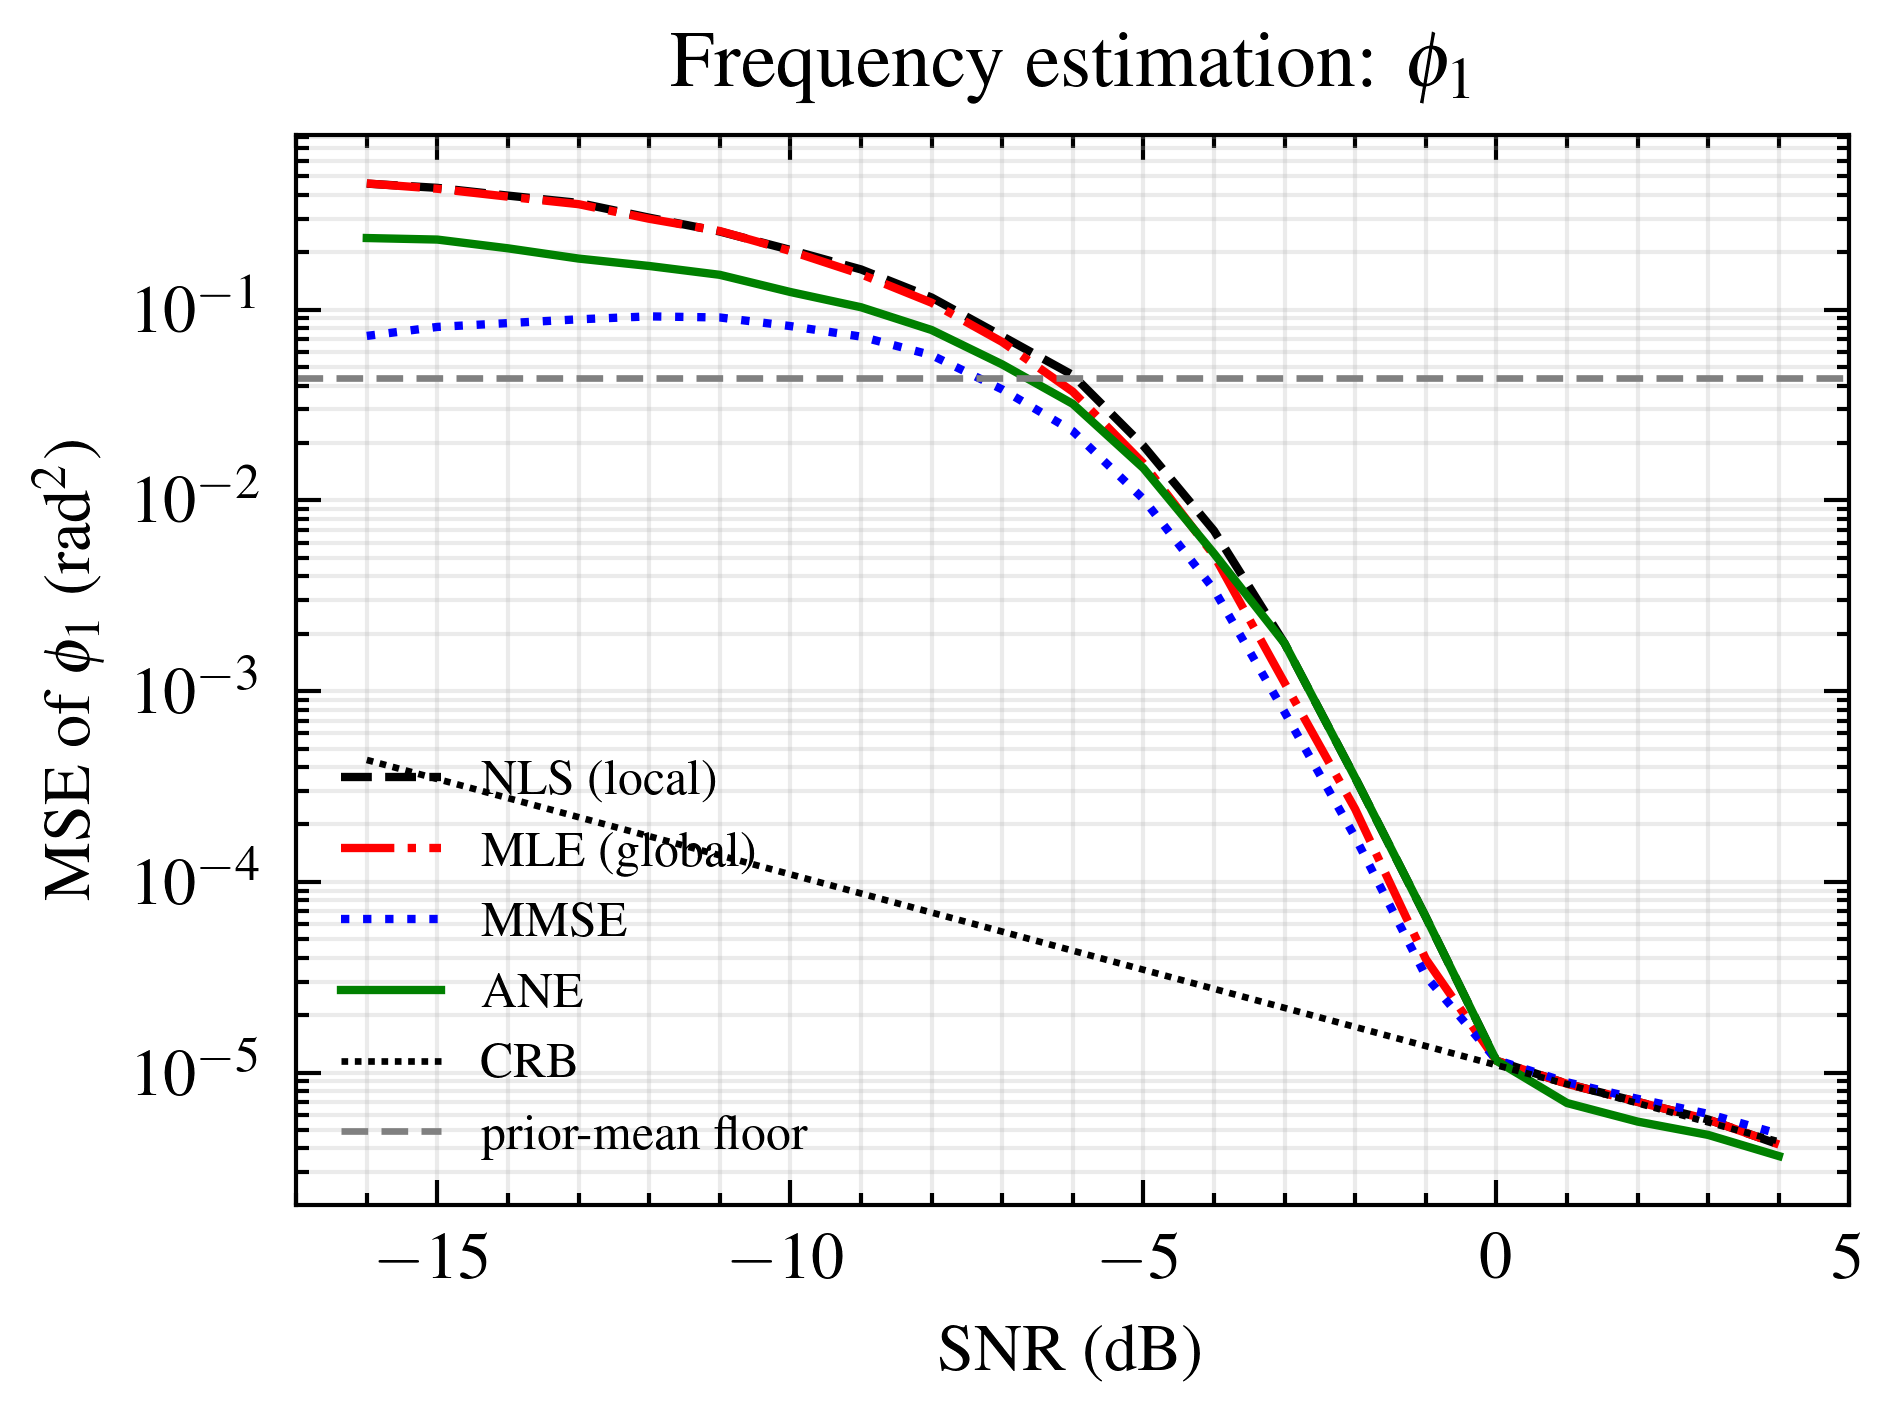

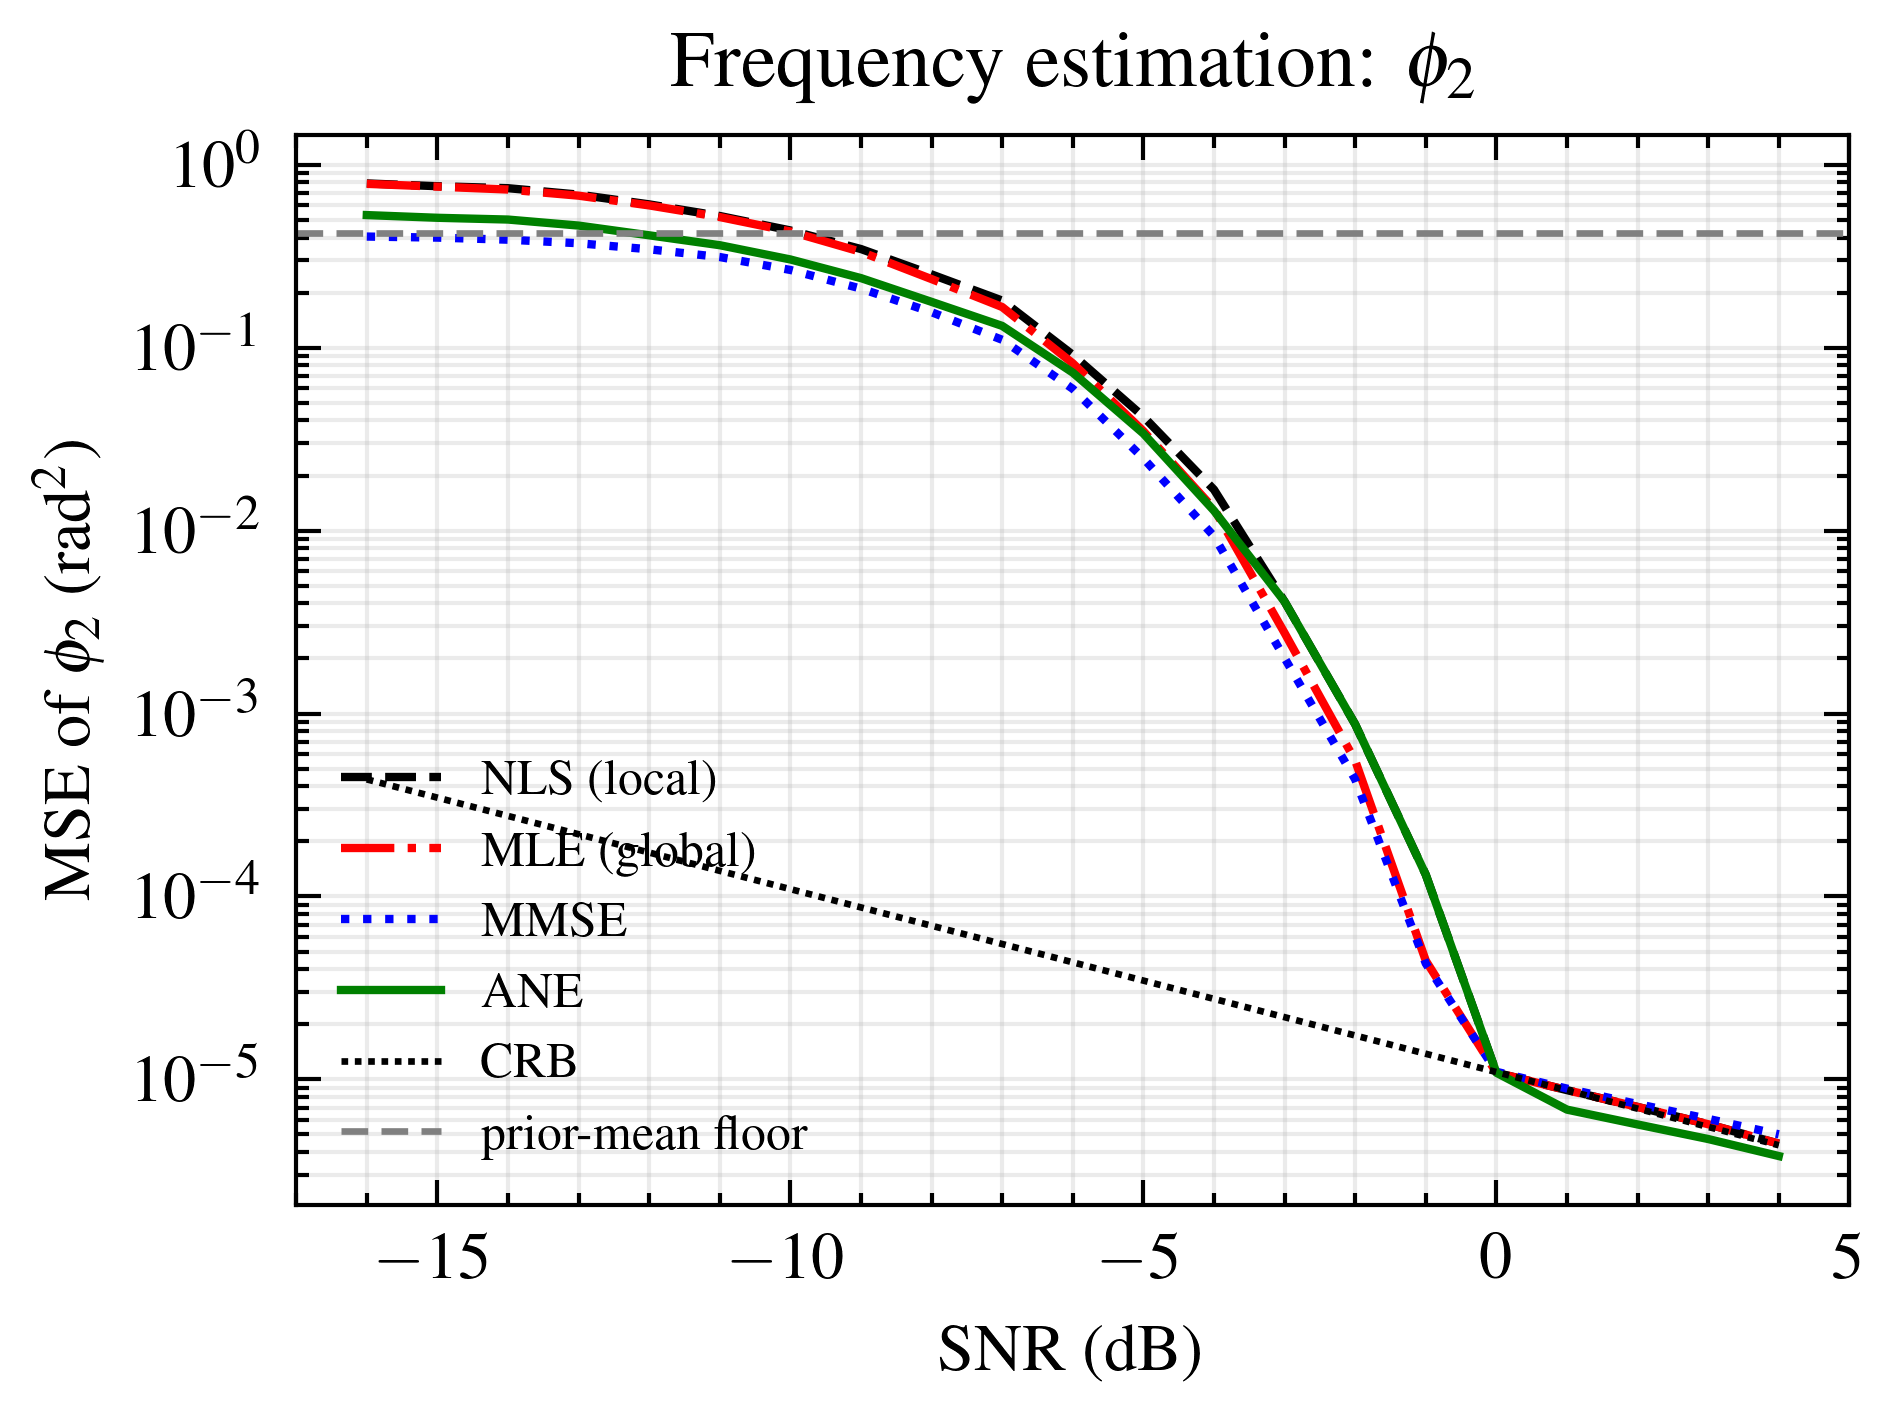

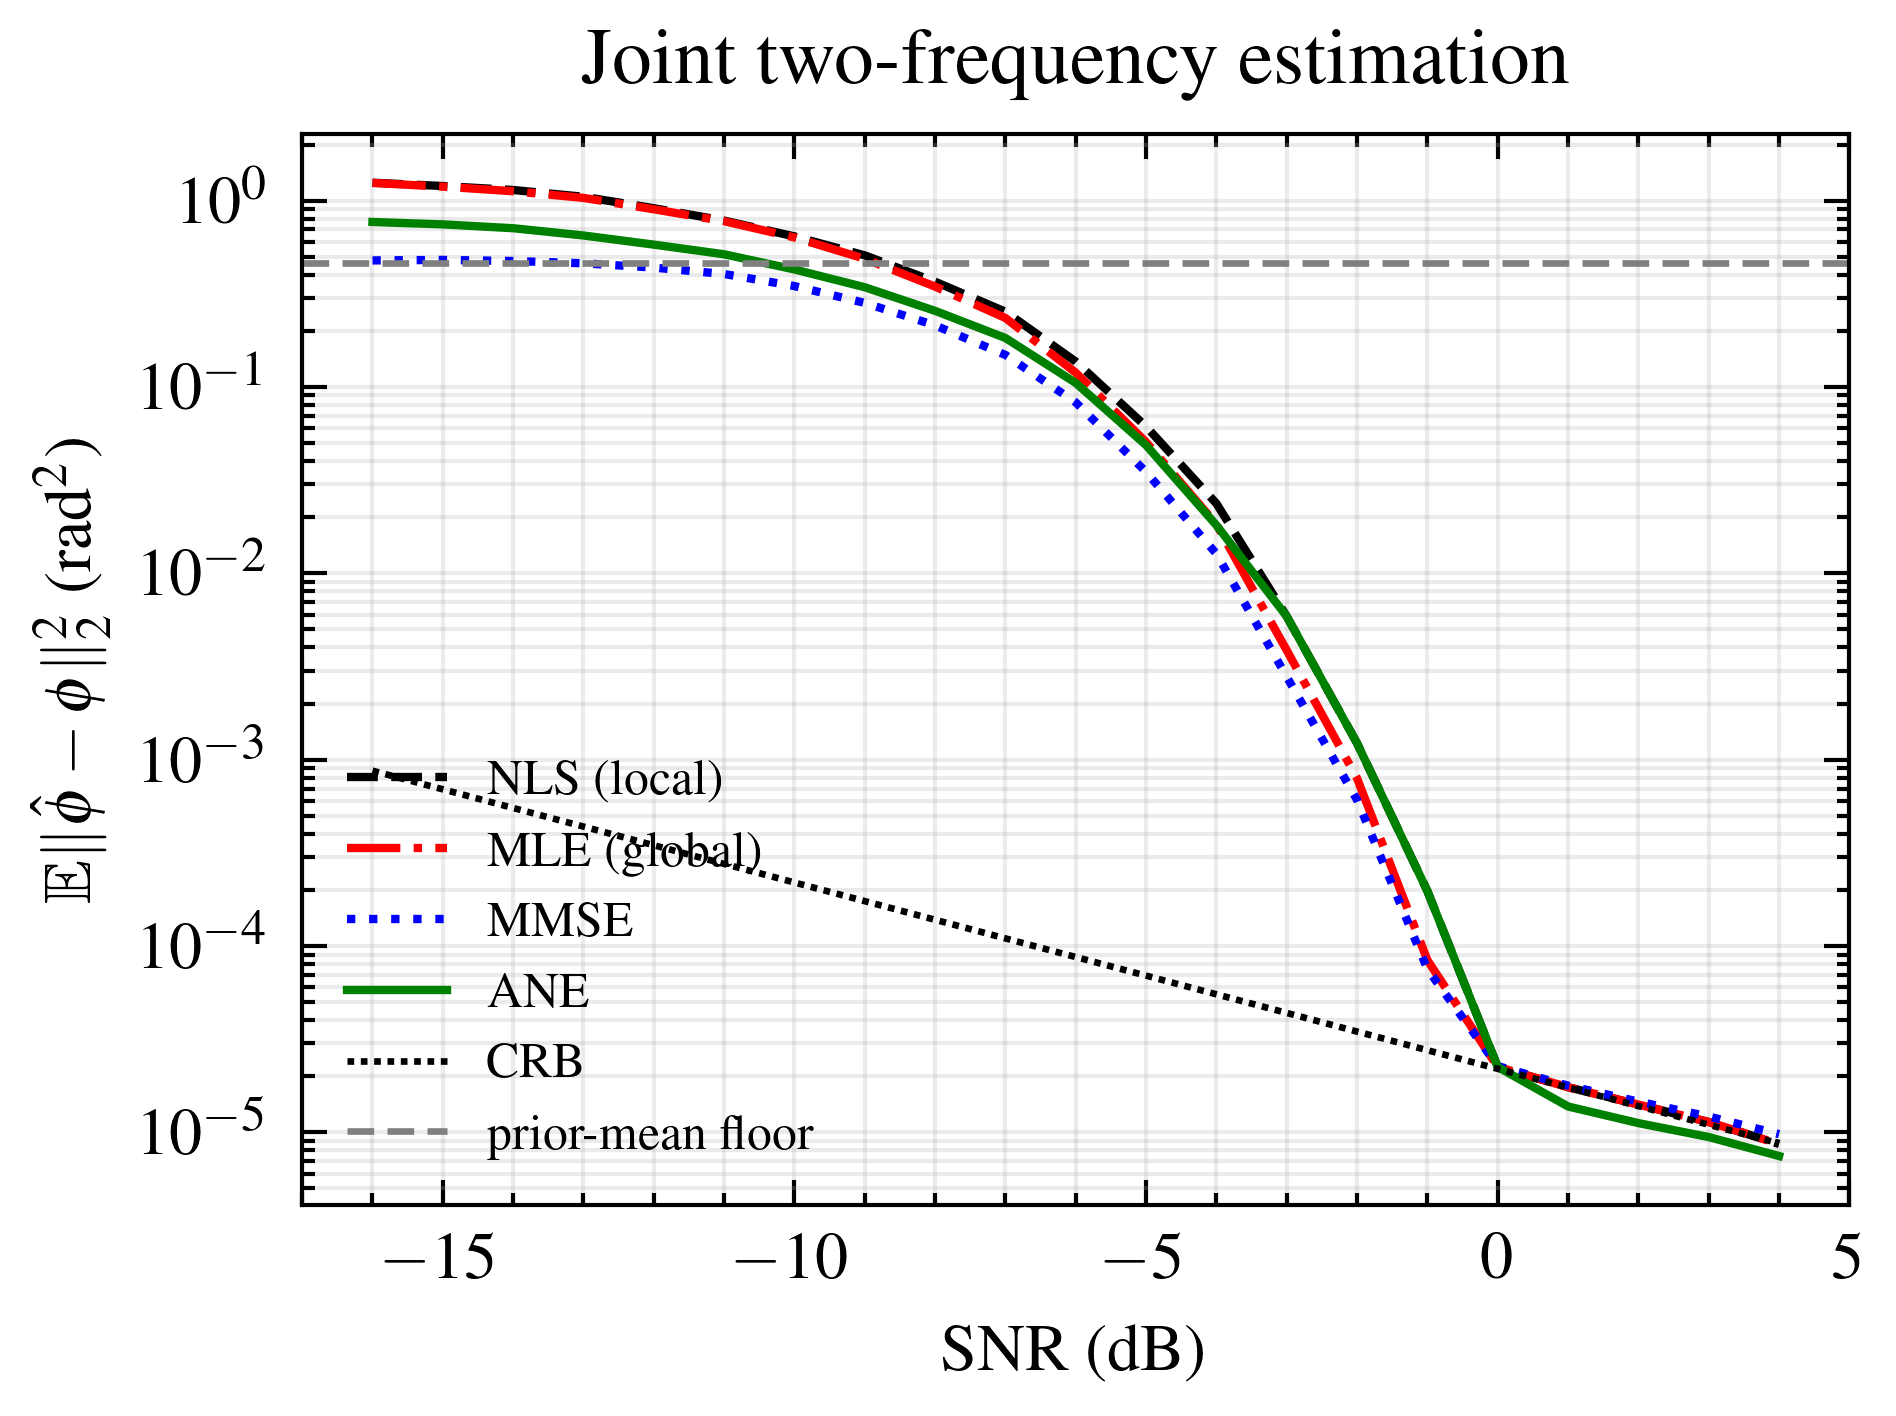

Loading separation results from fig_two_freq_separation_v3.npz...


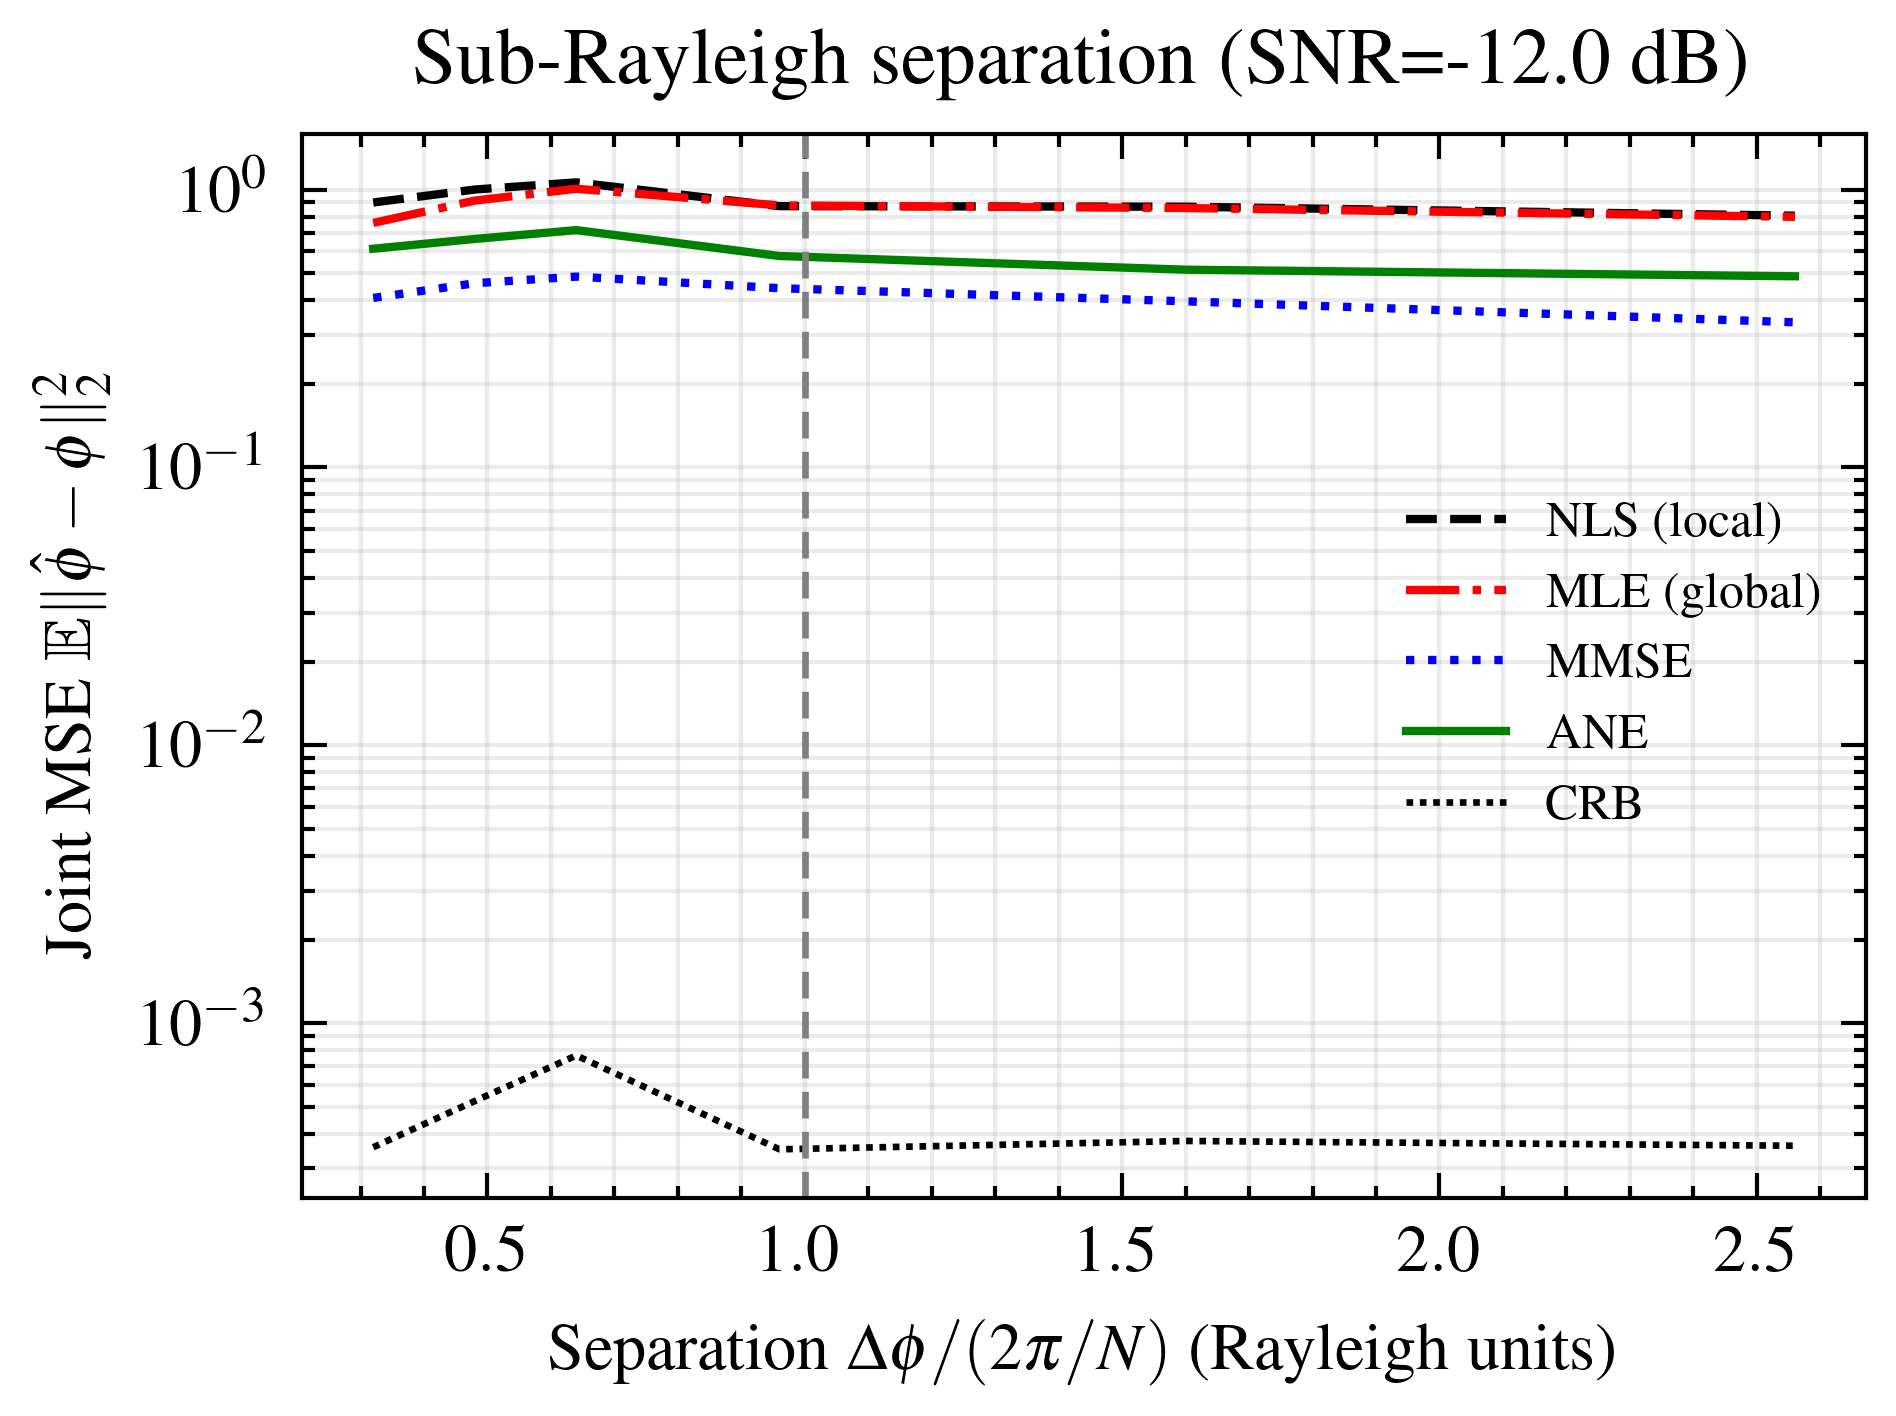

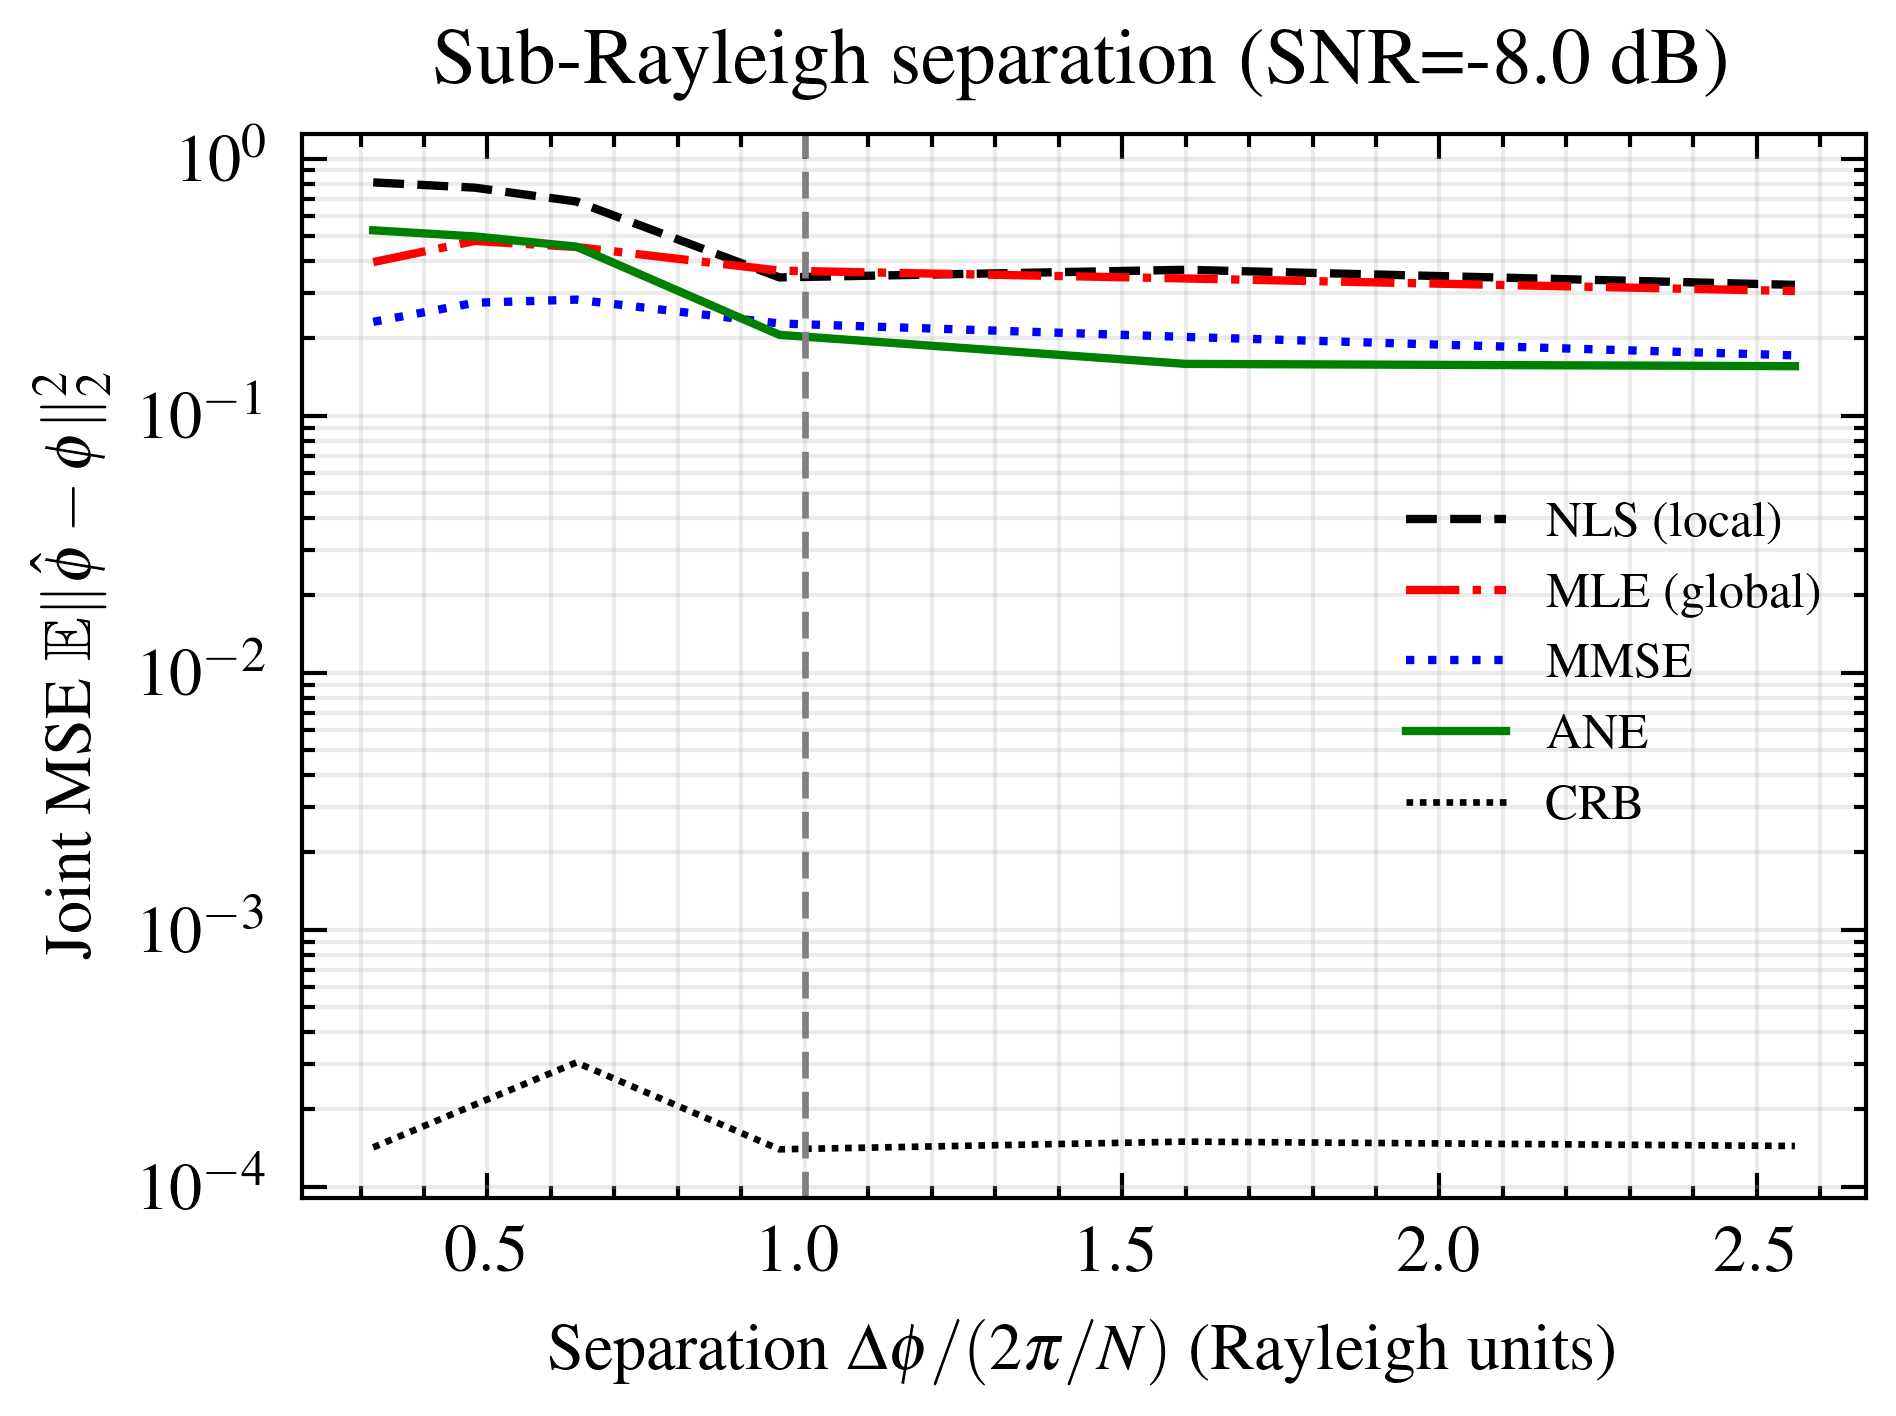

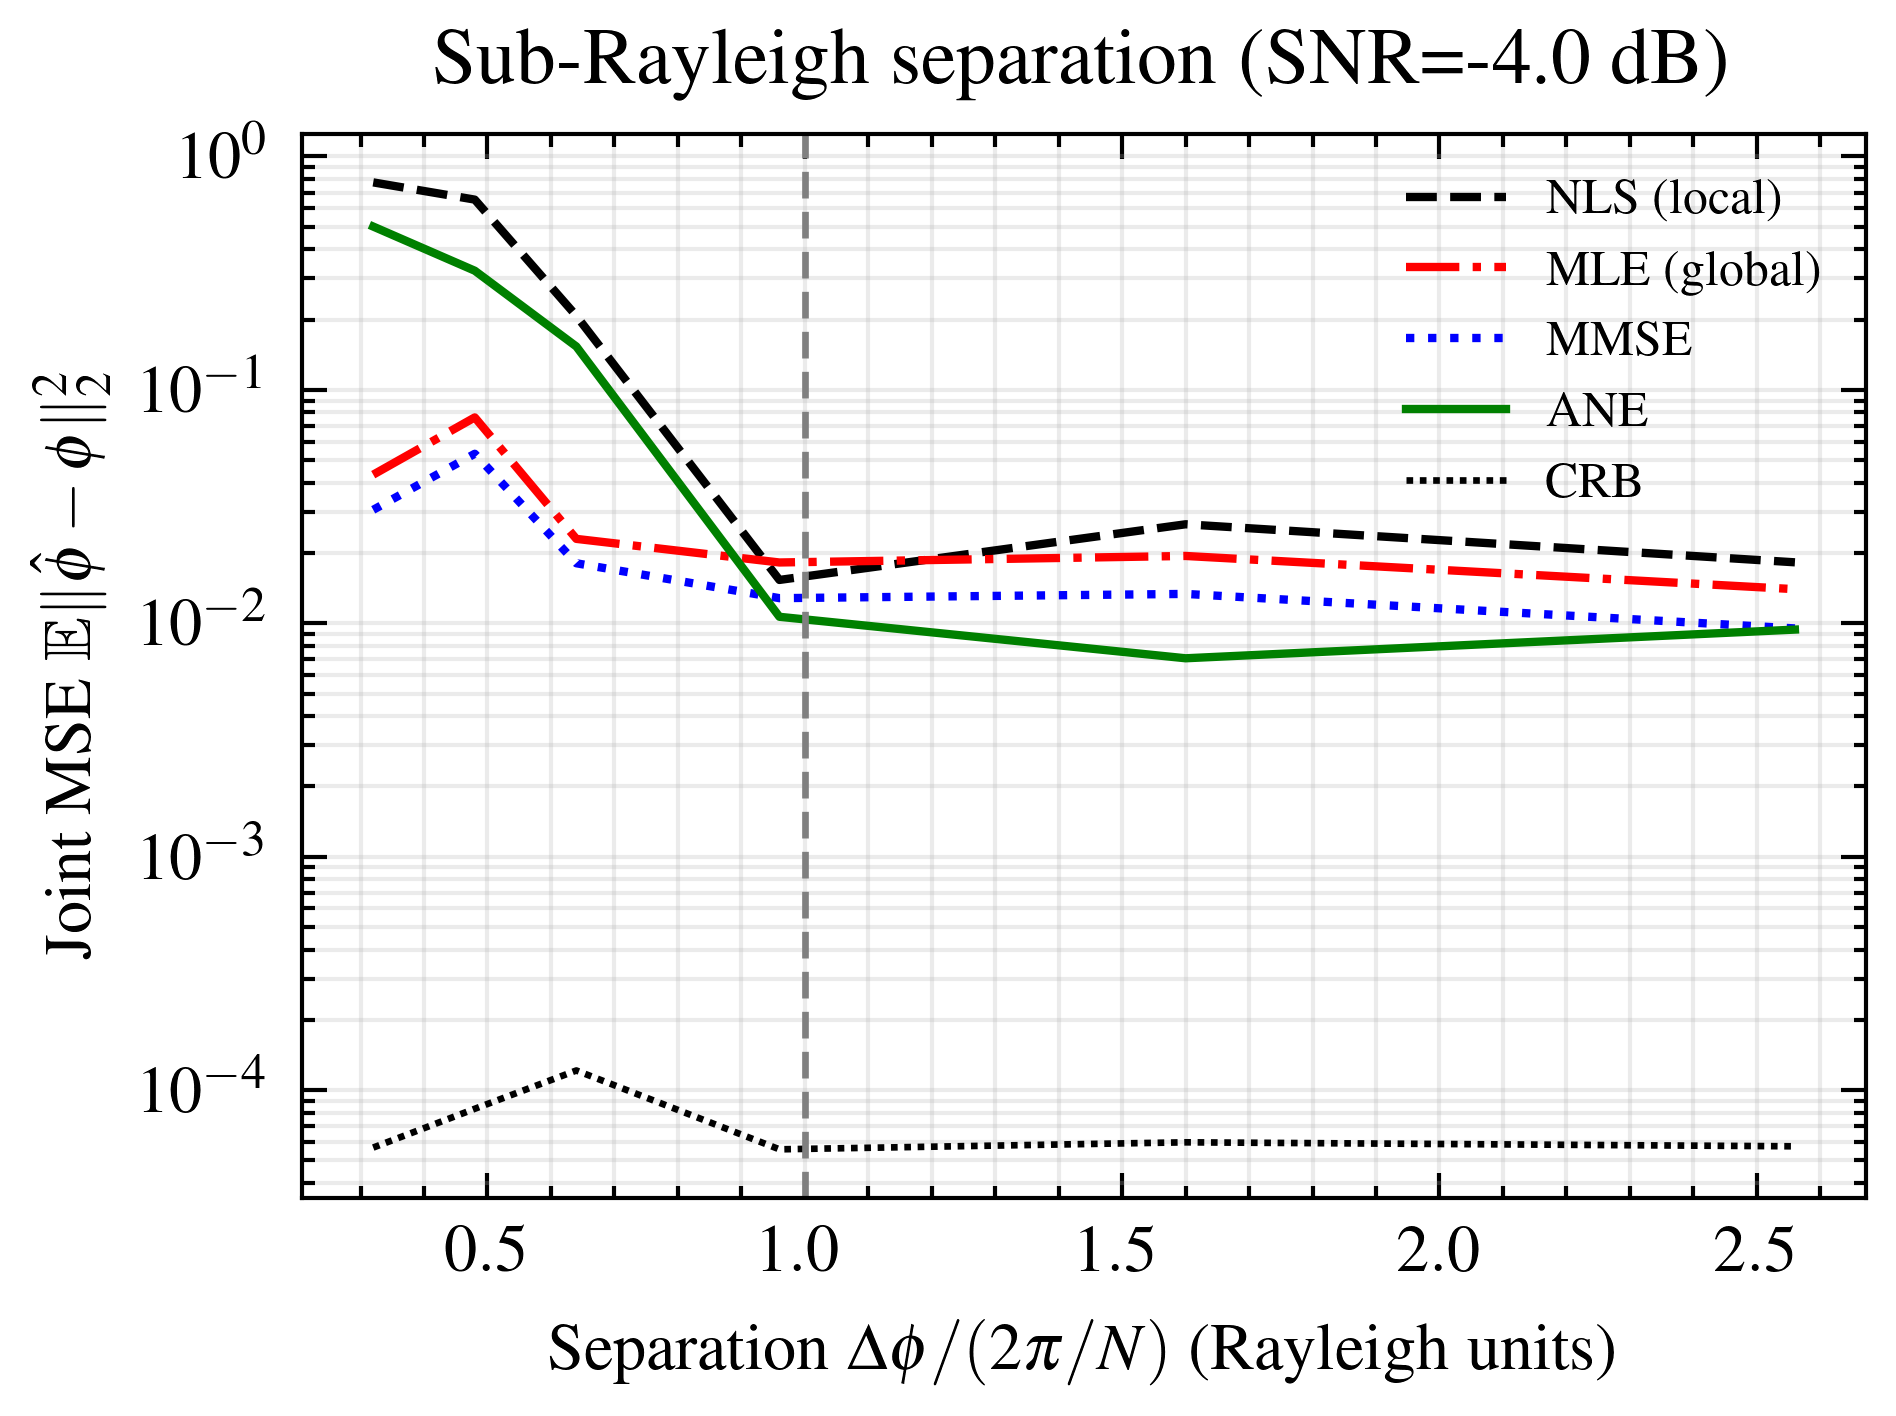

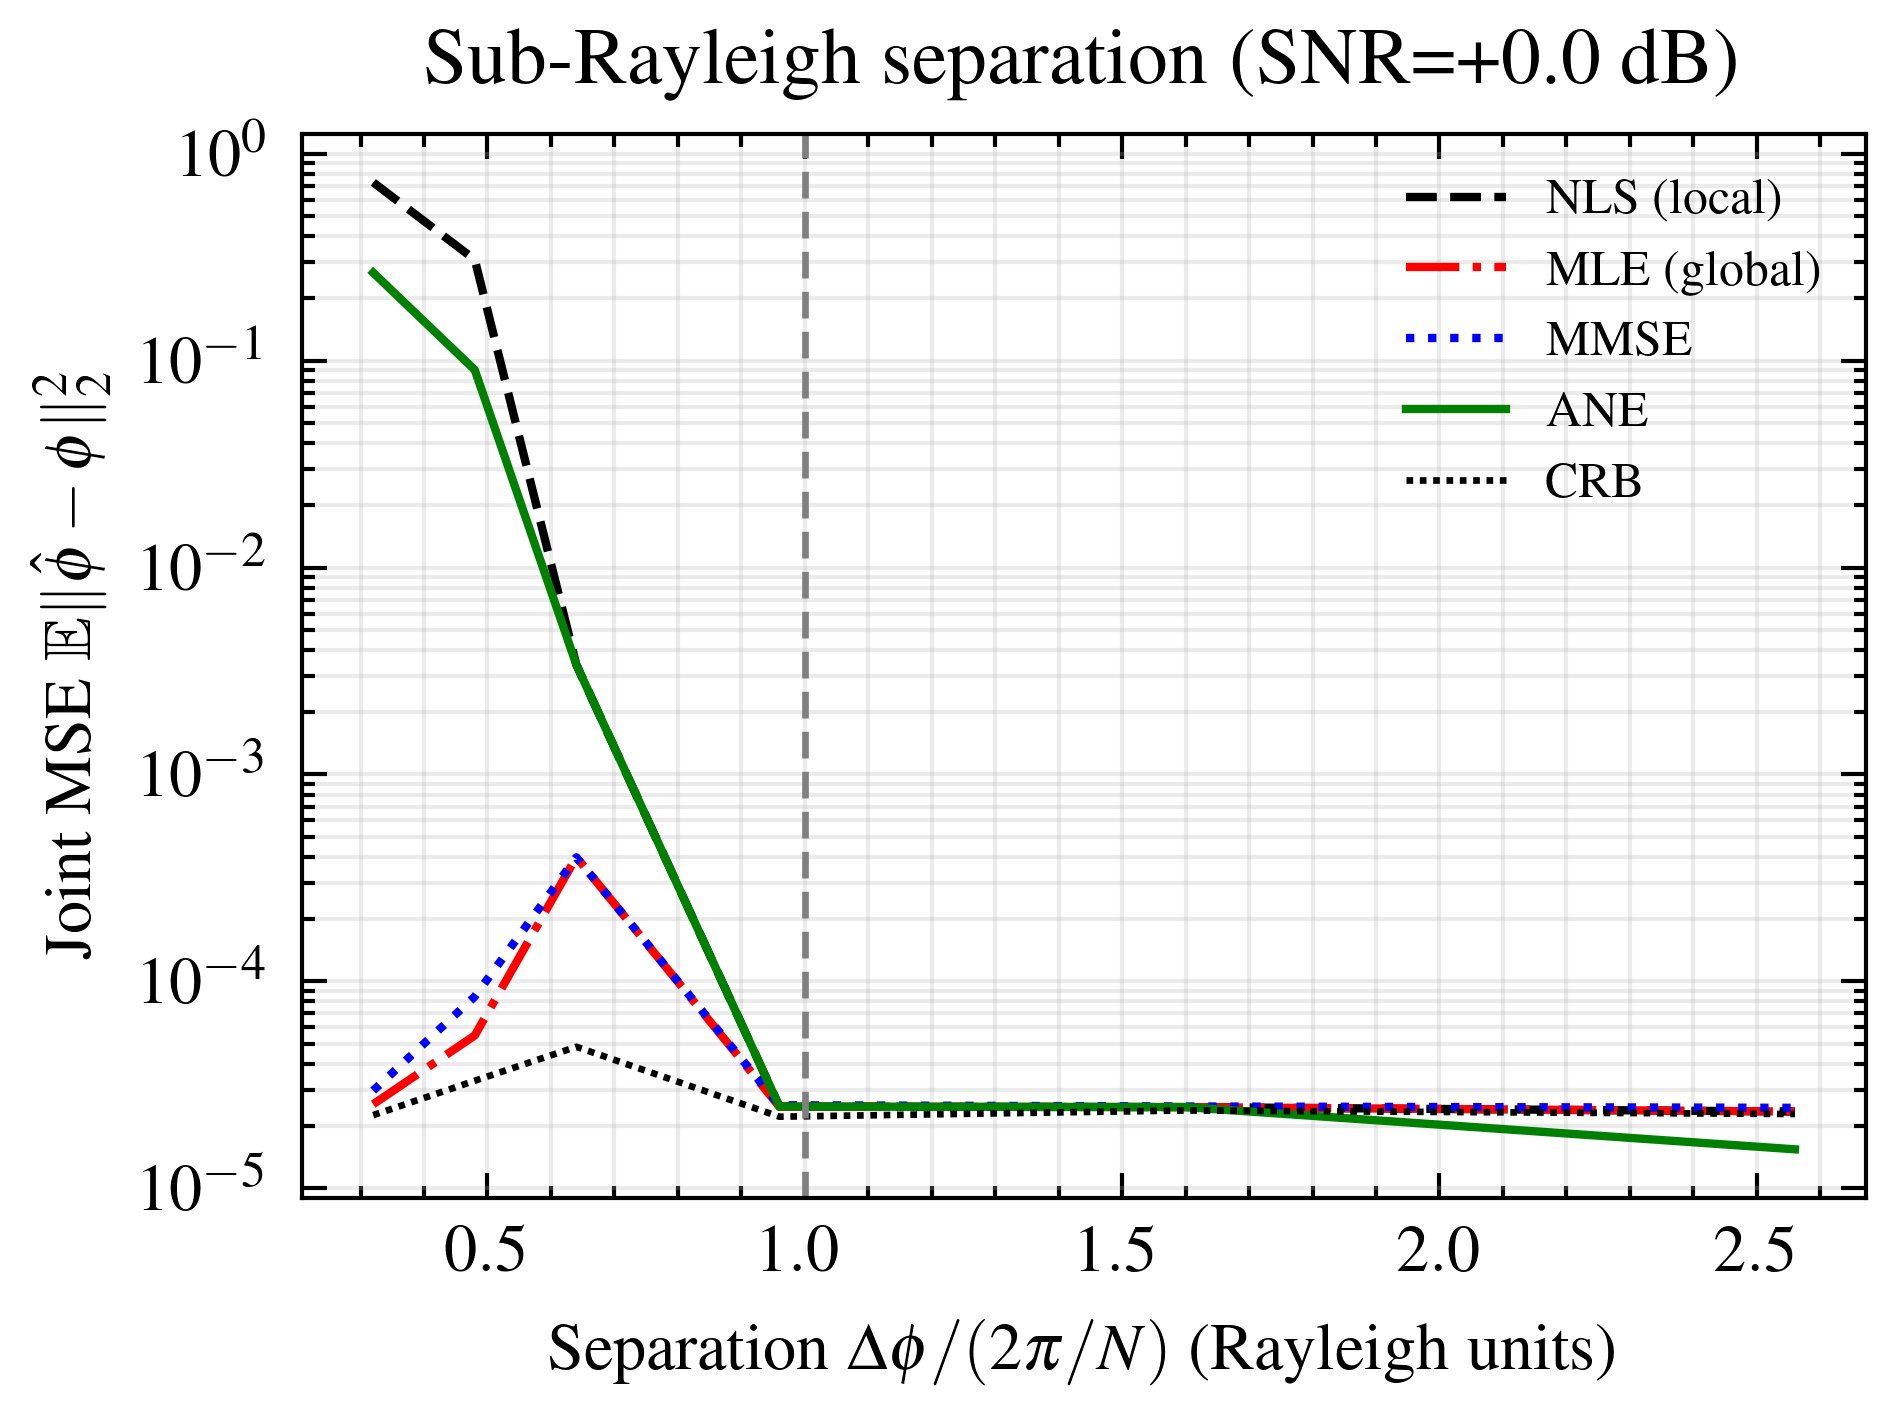

Loading robustness results from fig_two_freq_robustness_v3.npz...


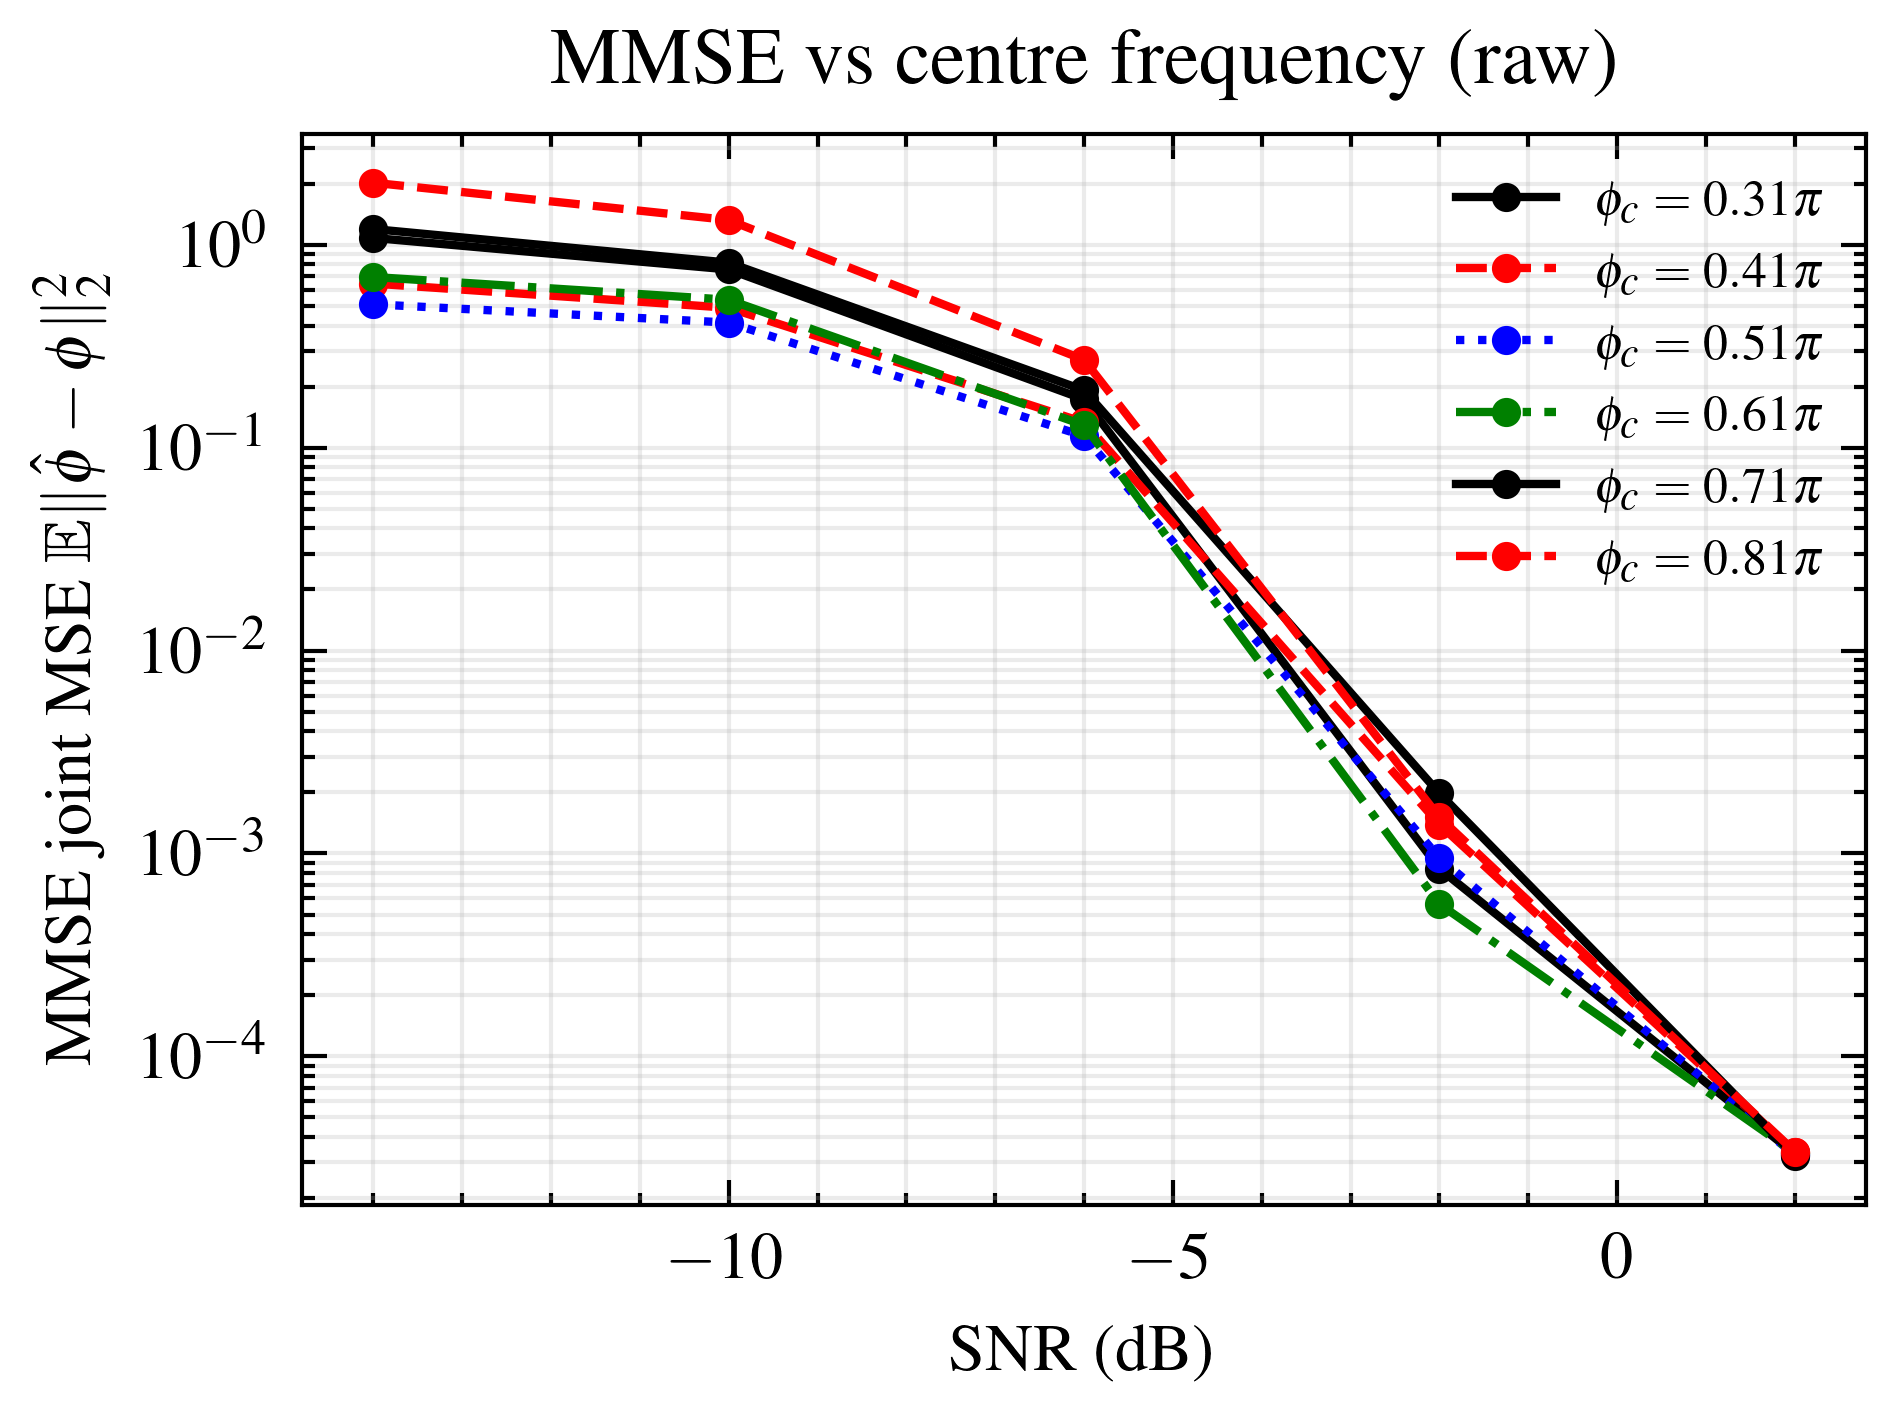

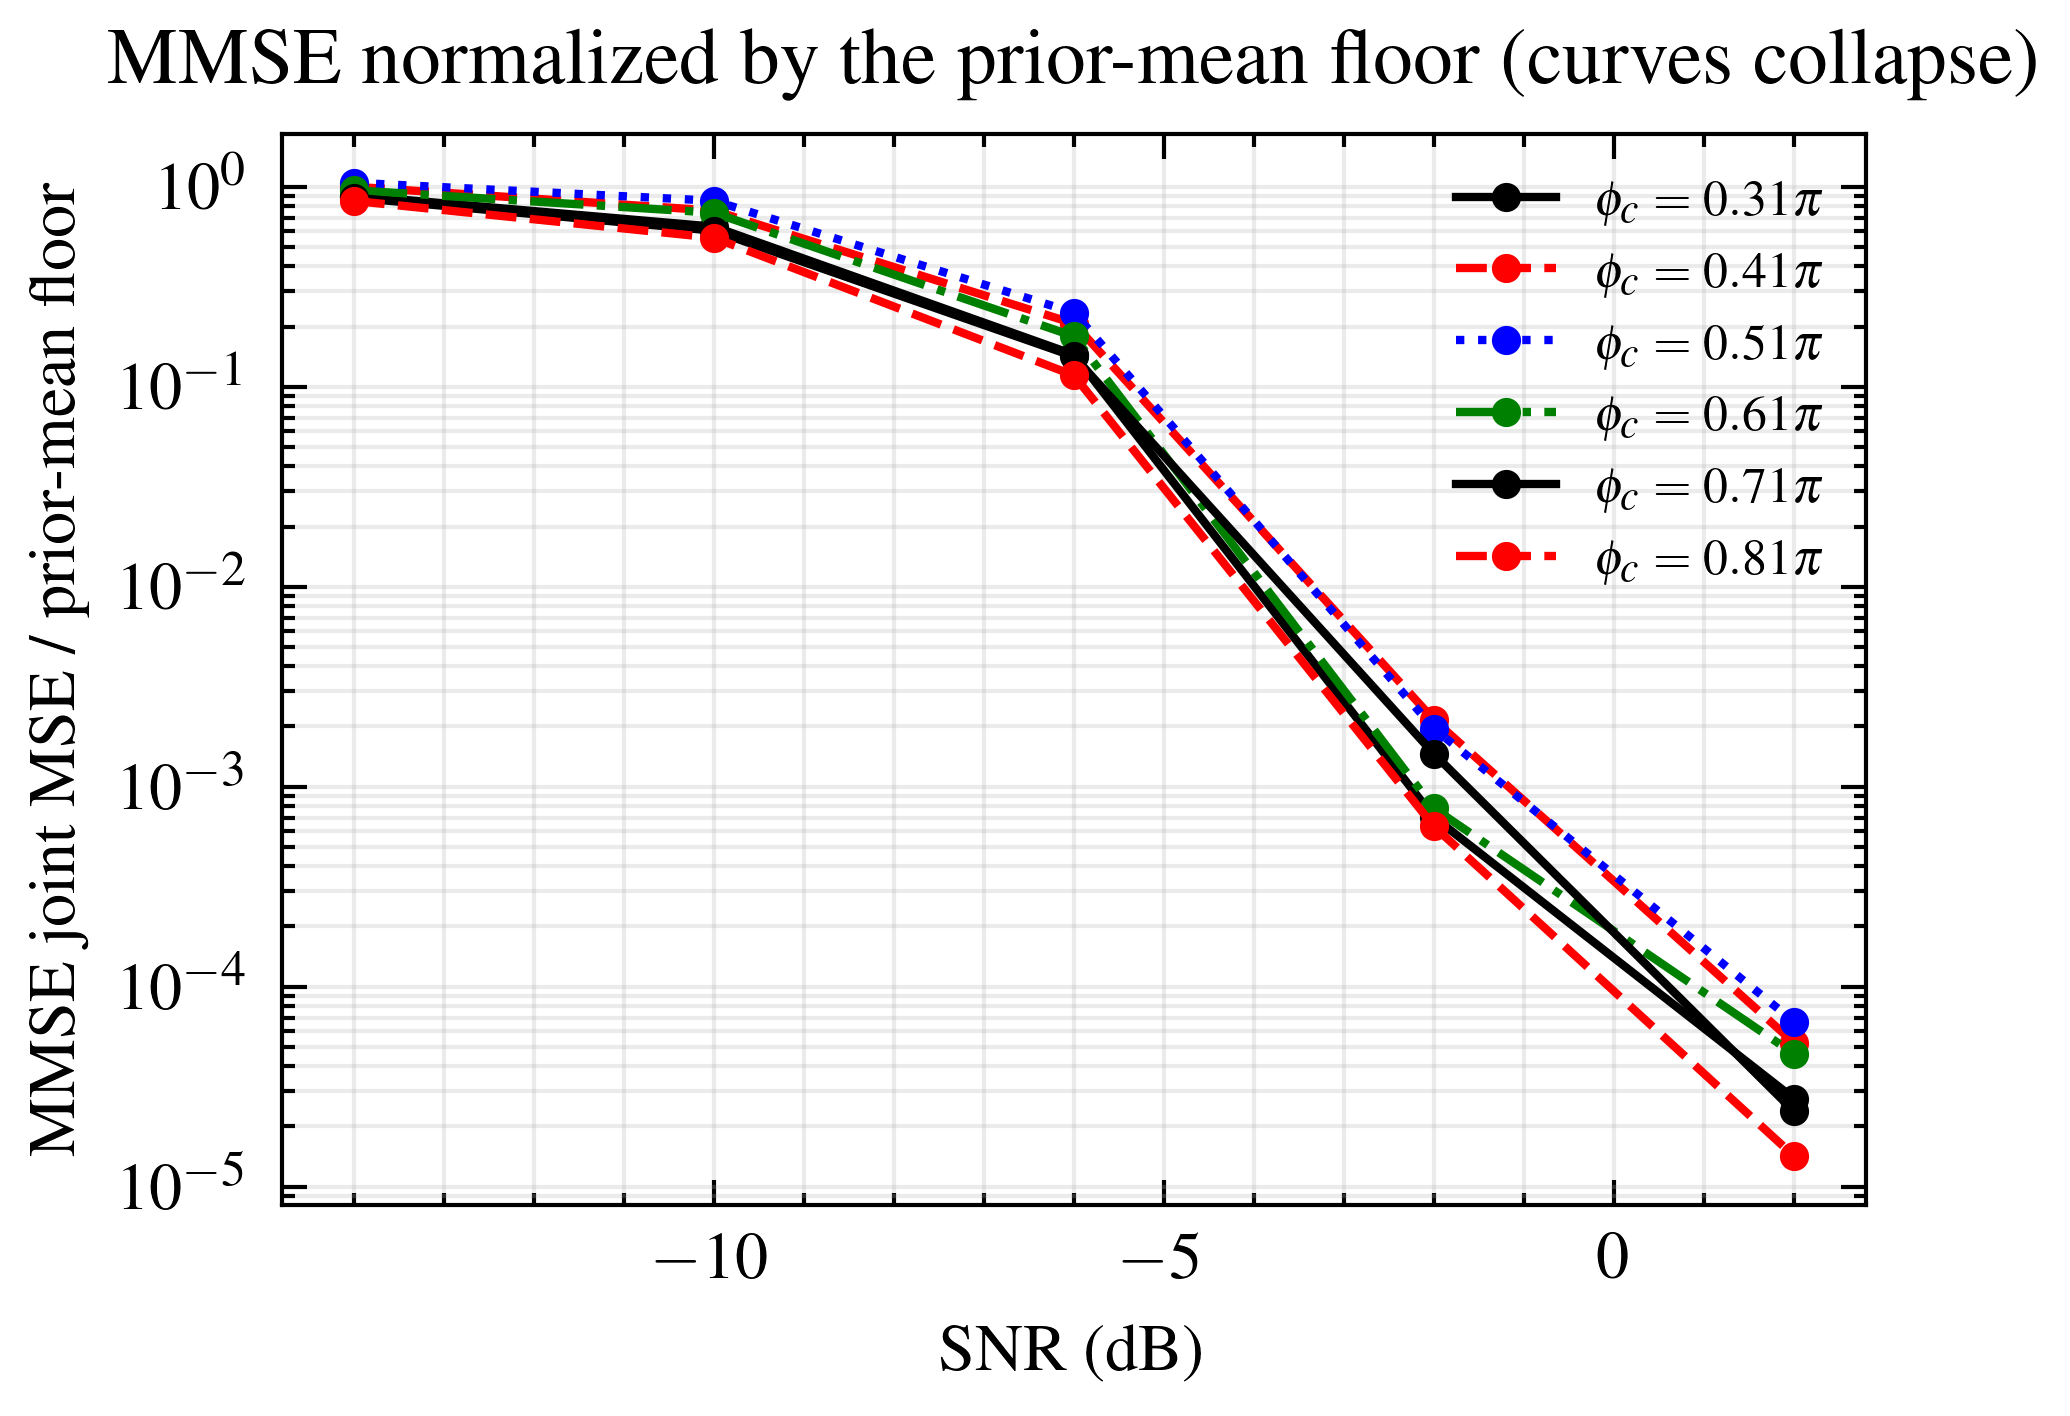

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
# ============================================================
# 0. 全局样式设置
# ============================================================
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "ieee"])
except Exception:
    print("Warning: scienceplots not available; using default matplotlib style.")

t0 = time.time()
set_all_seeds(SEED)

gam = 10.0 ** (SNR_DB / 10.0)
knee = (SNR_DB >= KNEE_DB[0]) & (SNR_DB <= KNEE_DB[1])

model = TwoFreqModel(
    N=N_SAMPLES, phi1_true=PHI1_TRUE, phi2_true=PHI2_TRUE
)

print("\n" + "=" * 62)
print("Two-frequency ANE experiment")
print("=" * 62)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"pair preset   : '{PAIR_CHOICE}'")

print("\nEstimator definitions:")
print("  NLS  : local nonlinear least squares")
print("  MLE  : global AWGN maximum likelihood")
print("         (same global objective as NLS)")
print("  MMSE : posterior mean under a uniform prior")
print("         over the ordered domain phi1 < phi2")
print("  ANE  : average of local NLS estimates")
print("         over an adaptive antithetic bank")
print("  CRB  : Cramer-Rao bound at theta_true")

print_pair_diagnostics(model, label=f"['{PAIR_CHOICE}']")

# --------------------------------------------------------
# Train ANE banks.
# --------------------------------------------------------
banks = train_all_snr_2f(
    model=model, gam=gam, knee=knee, seed0=700 + 13 * K
)

print("\nTraining completed.")

# --------------------------------------------------------
# Main Monte Carlo.
# --------------------------------------------------------
results = run_model_pytorch_2f(
    model=model, banks=banks, gam=gam, knee=knee
)

print("\nEstimation completed.")

# --------------------------------------------------------
# Save main results.
# --------------------------------------------------------
floor_c, floor_j = model.prior_floor()

flat = {
    "snr_db": SNR_DB,
    "phi1_true": model.phi1_true,
    "phi2_true": model.phi2_true,
    "center_pi": CENTER_PI,
    "sep_pi": SEP_PI,
    "sep_rayleigh": (model.phi2_true - model.phi1_true) / model.rayleigh,
    "N": model.N,
    "rayleigh": model.rayleigh,
    "separation": model.phi2_true - model.phi1_true,
    "grid_mmse_2d": model.G2,
    "grid_step": model.grid_step,
    "prior_mean": model.prior_mean(),
    "prior_floor_c0": floor_c[0],
    "prior_floor_c1": floor_c[1],
    "prior_floor_joint": floor_j,
    "dft_bin_offsets": model.dft_bin_offsets(),
    "node_distances": model.node_distances(),
}

for key in results:
    flat[key] = results[key]

np.savez(OUTPUT_NPZ, **flat)
print(f"Saved {OUTPUT_NPZ}")
# ============================================================
# 1. 绘制主实验结果 (c0, c1, joint)
# ============================================================
print(f"Loading main results from {OUTPUT_NPZ}...")
data = np.load(OUTPUT_NPZ)
snr = data["snr_db"]

floor_c0 = float(data["prior_floor_c0"])
floor_c1 = float(data["prior_floor_c1"])
floor_j = float(data["prior_floor_joint"])

panels = [
    (
        "c0",
        r"MSE of $\phi_1$ (rad$^2$)",
        r"Frequency estimation: $\phi_1$",
        "Fig_two_freq_phi1.pdf",
        floor_c0,
    ),
    (
        "c1",
        r"MSE of $\phi_2$ (rad$^2$)",
        r"Frequency estimation: $\phi_2$",
        "Fig_two_freq_phi2.pdf",
        floor_c1,
    ),
    (
        "joint",
        r"$\mathbb{E}\|\hat{\boldsymbol{\phi}}-\boldsymbol{\phi}\|_2^2$ (rad$^2$)",
        "Joint two-frequency estimation",
        OUTPUT_PDF, # 请确保此变量已定义，或替换为具体的字符串如 "Fig_two_freq_joint.pdf"
        floor_j,
    ),
]

for suffix, ylabel, title, fname, floor in panels:
    fig, ax = plt.subplots()

    # 依次绘制每种估计器的曲线
    ax.semilogy(snr, data[f"mse_nls_{suffix}"], label="NLS (local)", linestyle="--")
    ax.semilogy(snr, data[f"mse_mle_{suffix}"], label="MLE (global)", linestyle="-.")
    ax.semilogy(snr, data[f"mse_mmse_{suffix}"], label="MMSE", linestyle=":")
    ax.semilogy(snr, data[f"mse_ane_{suffix}"], label="ANE", linestyle="-")

    if f"crb_{suffix}" in data:
        ax.semilogy(snr, data[f"crb_{suffix}"], label="CRB", linestyle=(0, (1, 1)), color="k", linewidth=0.8)

    # 绘制先验下界 (Prior-mean floor)
    ax.axhline(floor, color="0.5", linewidth=0.8, linestyle=(0, (4, 2)), label="prior-mean floor")

    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=6)
    ax.grid(True, which="both", alpha=0.25)

    fig.tight_layout()
    fig.savefig(fname)
    plt.show()


# ============================================================
# 2. 绘制间距扫描结果 (Separation Sweep)
# ============================================================
if RUN_SEPARATION_SWEEP:
    print(f"Loading separation results from {OUTPUT_SEP_NPZ}...")
    sep_data = np.load(OUTPUT_SEP_NPZ, allow_pickle=True)
    sep_results = sep_data["results"].item()
    x = sep_data["separations_rayleigh"]

    for snr_db, vals in sep_results.items():
        fig, ax = plt.subplots()

        ax.semilogy(x, vals["nls"], label="NLS (local)", linestyle="--")
        ax.semilogy(x, vals["mle"], label="MLE (global)", linestyle="-.")
        ax.semilogy(x, vals["mmse"], label="MMSE", linestyle=":")
        ax.semilogy(x, vals["ane"], label="ANE", linestyle="-")
        
        ax.semilogy(x, vals["crb"], label="CRB", linestyle=(0, (1, 1)), color="k", linewidth=0.8)

        # 瑞利限垂直参考线
        ax.axvline(1.0, color="0.5", linewidth=0.8, linestyle=(0, (4, 2)))

        ax.set_xlabel(r"Separation $\Delta\phi / (2\pi/N)$ (Rayleigh units)")
        ax.set_ylabel(r"Joint MSE $\mathbb{E}\|\hat{\boldsymbol{\phi}}-\boldsymbol{\phi}\|_2^2$")
        ax.set_title(f"Sub-Rayleigh separation (SNR={snr_db:+.1f} dB)")
        
        ax.legend(loc="best", fontsize=6)
        ax.grid(True, which="both", alpha=0.25)

        fig.tight_layout()
        safe = str(snr_db).replace("-", "m").replace(".", "p")
        fig.savefig(f"Fig_separation_SNR_{safe}.pdf")
        plt.show()


# ============================================================
# 3. 绘制中心频率鲁棒性扫描结果 (Pair Robustness)
# ============================================================
if RUN_PAIR_ROBUSTNESS:
    print(f"Loading robustness results from {OUTPUT_ROBUST_NPZ}...")
    rob = np.load(OUTPUT_ROBUST_NPZ)
    snr_rob = rob["snr_db"]
    centers = rob["centers_pi"]
    floors = rob["prior_floor"]

    # 图 3.1: 原始 MMSE 曲线
    fig, ax = plt.subplots()
    for ci, c in enumerate(centers):
        ax.semilogy(
            snr_rob, rob["mmse"][ci], 
            marker="o", markersize=2.5, label=rf"$\phi_c={c:.2f}\pi$"
        )
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel(r"MMSE joint MSE $\mathbb{E}\|\hat{\boldsymbol{\phi}}-\boldsymbol{\phi}\|_2^2$")
    ax.set_title("MMSE vs centre frequency (raw)")
    ax.legend(loc="best", fontsize=6)
    ax.grid(True, which="both", alpha=0.25)
    
    fig.tight_layout()
    fig.savefig("Fig_pair_robustness_raw.pdf")
    plt.show()

    # 图 3.2: 归一化后的 MMSE 曲线
    fig, ax = plt.subplots()
    for ci, c in enumerate(centers):
        ax.semilogy(
            snr_rob, rob["mmse"][ci] / floors[ci], 
            marker="o", markersize=2.5, label=rf"$\phi_c={c:.2f}\pi$"
        )
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("MMSE joint MSE / prior-mean floor")
    ax.set_title("MMSE normalized by the prior-mean floor (curves collapse)")
    ax.legend(loc="best", fontsize=6)
    ax.grid(True, which="both", alpha=0.25)
    
    fig.tight_layout()
    fig.savefig("Fig_pair_robustness_normalized.pdf")
    plt.show()

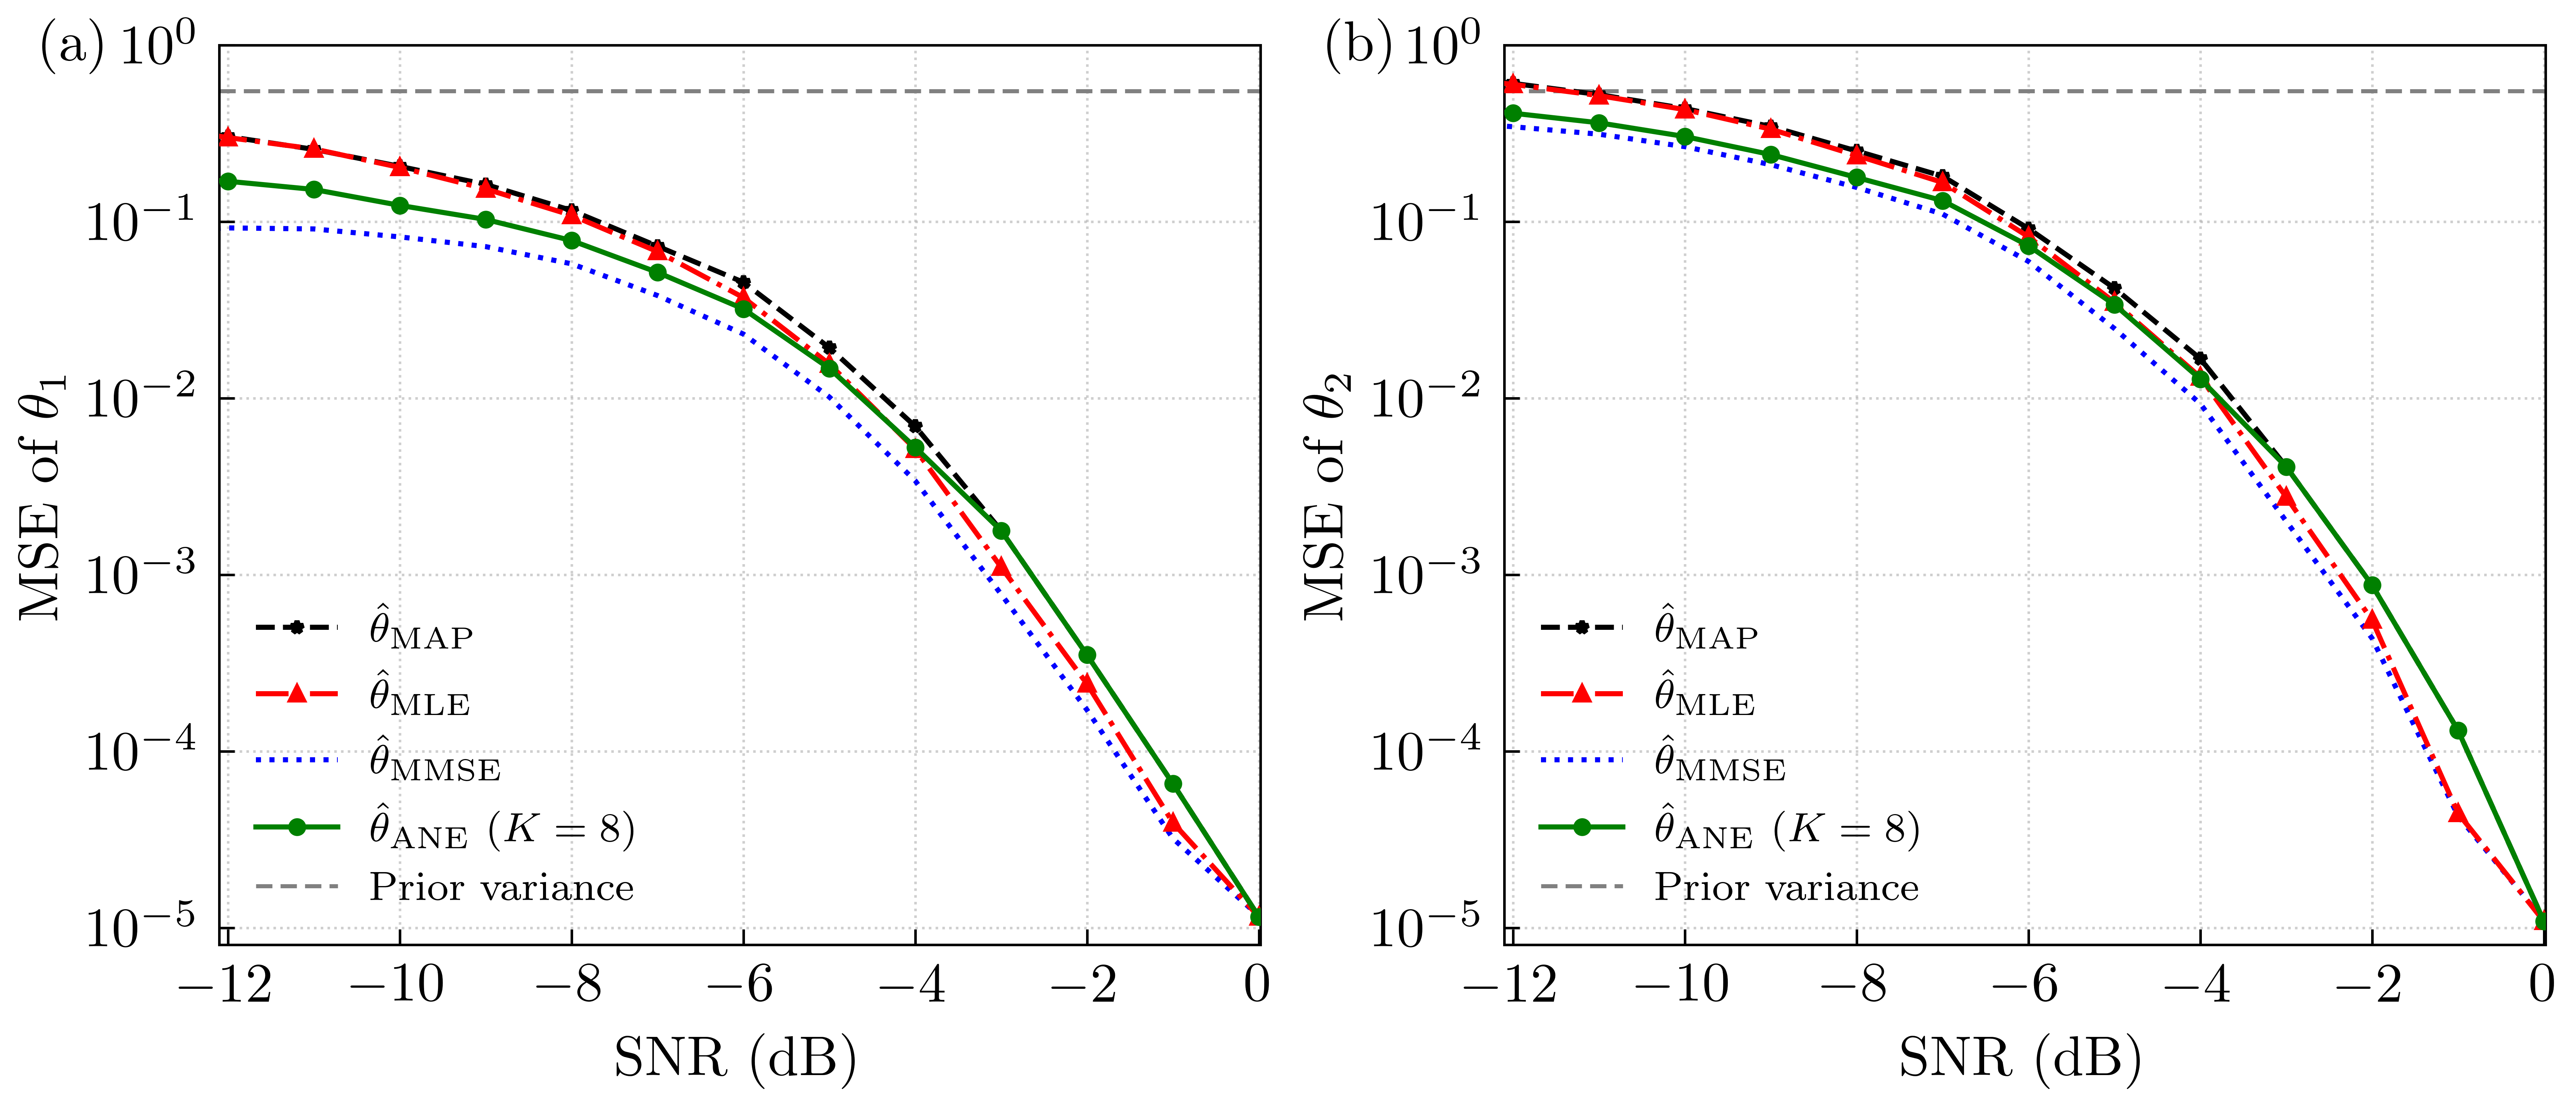

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
# =========================================================================
# Global academic style: SciencePlots + IEEE
# =========================================================================
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 8,
    'axes.labelsize'    : 8,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 1000,
    'axes.unicode_minus': False,
})

# =========================================================================
# Combined IEEE two-column figure
# =========================================================================
fig, (ax_s, ax_m) = plt.subplots(
    1, 2,
    figsize=(7, 3),
    constrained_layout=True
)

# 注意：这里假设 snr 和 data 已经在你的上下文中定义好了。
# 例如：
# snr = np.arange(0, 35, 5)
# data = { ... }
data=np.load("fig_two_freq_results_v3.npz")
snr = data["snr_db"] # 假设 SNR 数组也保存在字典中
# =========================================================================
# (a) MSE of phi1 (c0)
# =========================================================================
ax_s.grid(True, which="both", alpha=0.25)
ax_s.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)

ax_s.semilogy(snr, data["mse_nls_c0"], label=r"$\hat\theta_{\mathrm{MAP}}$", marker="*", ms=2.5, zorder=4, linestyle="--", color="C0")
ax_s.semilogy(snr, data["mse_mle_c0"], label=r"$\hat\theta_{\mathrm{MLE}}$", marker="^", ms=2.5, zorder=4, linestyle="-.", color="C1")
ax_s.semilogy(snr, data["mse_mmse_c0"], label=r"$\hat\theta_{\mathrm{MMSE}}$", linestyle=":", color="C2")
ax_s.semilogy(snr, data["mse_ane_c0"], label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K=8)$", marker="o", ms=2.5, zorder=4, linestyle="-", color="C3")

# 先验下界：c0 的 prior-mean floor
ax_s.axhline(
    0.5483, 
    color="0.5", 
    linewidth=0.8, 
    linestyle=(0, (4, 2)), 
    label="Prior variance"
)

ax_s.set_xlabel("SNR (dB)", fontsize=11)
ax_s.set_ylabel(r"MSE of $\theta_1$", fontsize=11)
ax_s.tick_params(axis='both', labelsize=11)

ax_s.legend(
    loc="lower left",
    fontsize=8
)

# Panel label
ax_s.text(
    -0.17, 1.03,
    r'$\mathrm{(a)}$',
    transform=ax_s.transAxes,
    ha='left',
    va='top',
    fontsize=11
)
ax_s.set_xticks([-12, -10, -8,-6, -4, -2, 0, 2])
ax_s.set_xlim([-12.1, 0.02])
ax_s.set_ylim([0.000008,1])
# 关闭 minor ticks
ax_s.minorticks_off()

# 只给主刻度画网格
ax_s.grid(which="major", ls=":", alpha=0.6)
# =========================================================================
# (b) MSE of phi2 (c1)
# =========================================================================
ax_m.grid(True, which="both", alpha=0.25)
ax_m.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)

ax_m.semilogy(snr, data["mse_nls_c1"], label=r"$\hat\theta_{\mathrm{MAP}}$", marker="*", ms=2.5, zorder=4, linestyle="--", color="C0")
ax_m.semilogy(snr, data["mse_mle_c1"], label=r"$\hat\theta_{\mathrm{MLE}}$", marker="^", ms=2.5, zorder=4, linestyle="-.", color="C1")
ax_m.semilogy(snr, data["mse_mmse_c1"], label=r"$\hat\theta_{\mathrm{MMSE}}$", linestyle=":", color="C2")
ax_m.semilogy(snr, data["mse_ane_c1"], label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K=8)$", marker="o", ms=2.5, zorder=4, linestyle="-", color="C3")

ax_m.axhline(
    0.5483, 
    color="0.5", 
    linewidth=0.8, 
    linestyle=(0, (4, 2)), 
    label="Prior variance"
)

ax_m.set_xlabel("SNR (dB)", fontsize=11)
ax_m.set_ylabel(r"MSE of $\theta_2$", fontsize=11)
ax_m.tick_params(axis='both', labelsize=11)

ax_m.legend(
    loc="lower left",
    fontsize=8
)

# Panel label
ax_m.text(
    -0.17,1.03,
    r'$\mathrm{(b)}$',
    transform=ax_m.transAxes,
    ha='left',
    va='top',
    fontsize=11
)
ax_m.set_xticks([-12, -10, -8,-6, -4, -2, 0, 2])
ax_m.set_xlim([-12.1, 0.02])
ax_m.set_ylim([0.000008,1])
# 关闭 minor ticks
ax_m.minorticks_off()

# 只给主刻度画网格
ax_m.grid(which="major", ls=":", alpha=0.6)
# =========================================================================
# Save & Show
# =========================================================================
# 不再需要紧凑布局因为初始化中设置了 constrained_layout=True
fig.savefig("D:/Fig3-1.pdf", dpi=1000)
plt.show()

In [4]:
data

NpzFile 'fig_two_freq_results_v3.npz' with keys: snr_db, phi1_true, phi2_true, center_pi, sep_pi...